# 🥦 Perishable Goods Management — XGBoost vs CatBoost

---

**Dataset :** Managing Perishable Inventory Data  
**Target   :** `was_spoiled` (Binary Classification — 0 = Tidak Busuk, 1 = Busuk)  
**Algoritma:** XGBoost & CatBoost  
**Tujuan   :** Memprediksi apakah produk akan busuk sebelum terjual, serta membandingkan performa kedua algoritma secara menyeluruh

---

## 📋 Daftar Isi
1. [Setup & Instalasi](#1)
2. [Load Dataset](#2)
3. [Exploratory Data Analysis (EDA)](#3)
4. [Preprocessing & Feature Engineering](#4)
5. [Teori Algoritma — XGBoost](#5)
6. [Teori Algoritma — CatBoost](#6)
7. [Training Model XGBoost](#7)
8. [Training Model CatBoost](#8)
9. [Evaluasi & Metrik Performa](#9)
10. [Visualisasi Perbandingan](#10)
11. [Feature Importance](#11)
12. [Kesimpulan & Rekomendasi](#12)


## 1. ⚙️ Setup & Instalasi <a id='1'></a>

In [ ]:
# Install library yang dibutuhkan
!pip install xgboost catboost kagglehub imbalanced-learn shap -q

import warnings
warnings.filterwarnings('ignore')
print("✅ Instalasi selesai!")


✅ Instalasi selesai!


In [ ]:
# Import semua library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import Counter

# Sklearn — preprocessing & metrics
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, learning_curve
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve, average_precision_score,
    matthews_corrcoef, log_loss
)
from sklearn.inspection import permutation_importance

# Algoritma utama
from xgboost import XGBClassifier
from catboost import CatBoostClassifier, Pool

# SHAP untuk interpretasi model
import shap

# Imbalanced-learn
from imblearn.over_sampling import SMOTE

import time
import os

# Style plot
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_palette("husl")

print("✅ Semua library berhasil diimport!")
print(f"   NumPy     : {np.__version__}")
print(f"   Pandas    : {pd.__version__}")
print(f"   XGBoost   : {__import__('xgboost').__version__}")
print(f"   CatBoost  : {__import__('catboost').__version__}")


✅ Semua library berhasil diimport!
   NumPy     : 2.0.2
   Pandas    : 2.2.2
   XGBoost   : 3.2.0
   CatBoost  : 1.2.10


## 2. 📂 Load Dataset <a id='2'></a>

Dataset diunduh dari Kaggle menggunakan `kagglehub`. Jika sudah memiliki file CSV, bisa langsung di-upload ke Colab dan load langsung.


In [ ]:
# Cara 1: Download dari Kaggle (butuh Kaggle API Key)
# import kagglehub
# path = kagglehub.dataset_download("minahilfatima12328/managing-perishable-inventory-data")
# csv_path = os.path.join(path, os.listdir(path)[0])
# df = pd.read_csv(csv_path)

# Cara 2: Upload CSV manual ke Colab, lalu load
# from google.colab import files
# uploaded = files.upload()
# df = pd.read_csv(list(uploaded.keys())[0])

# ─── UNTUK DEMO: load dari path lokal ───────────────────────────────────────
# Ganti path ini sesuai file CSV Anda
CSV_PATH = "perishable_goods_management.csv"   # ← sesuaikan nama file
df = pd.read_csv(CSV_PATH)

print(f"✅ Dataset berhasil dimuat!")
print(f"   Jumlah baris    : {df.shape[0]:,}")
print(f"   Jumlah kolom    : {df.shape[1]}")
print(f"\nInfo kolom:")
df.info()


✅ Dataset berhasil dimuat!
   Jumlah baris    : 100,000
   Jumlah kolom    : 42

Info kolom:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 42 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   record_id                   100000 non-null  int64  
 1   product_id                  100000 non-null  object 
 2   product_name                100000 non-null  object 
 3   category                    100000 non-null  object 
 4   store_id                    100000 non-null  object 
 5   region                      100000 non-null  object 
 6   supplier_id                 100000 non-null  object 
 7   transaction_date            100000 non-null  object 
 8   expiration_date             100000 non-null  object 
 9   shelf_life_days             100000 non-null  int64  
 10  days_remaining_at_purchase  100000 non-null  int64  
 11  storage_temp                100000 non

In [ ]:
# Preview data
print("=== 5 Baris Pertama ===")
display(df.head())

print("\n=== Statistik Deskriptif ===")
display(df.describe().round(3))

print("\n=== Missing Values ===")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "Tidak ada missing values ✅")

print(f"\n=== Distribusi Target (was_spoiled) ===")
vc = df['was_spoiled'].value_counts()
for k, v in vc.items():
    label = "Busuk" if k == 1 else "Tidak Busuk"
    print(f"  {k} ({label}) : {v:>6,} ({v/len(df)*100:.1f}%)")


=== 5 Baris Pertama ===


,record_id,product_id,product_name,category,store_id,region,supplier_id,transaction_date,expiration_date,shelf_life_days,...,selling_price,units_sold,units_wasted,waste_pct,revenue,waste_cost,profit,profit_margin_pct,supplier_score,is_promoted
0,1,BAK_DON_743,Donuts,Bakery,STORE_046,West,SUPPLIER_03,2024-09-25,2024-09-29,4,...,2.60,138,20,12.7,358.80,24.40,166.04,46.3,9,0
1,2,MEA_SAU_338,Sausages,Meat,STORE_030,Southwest,SUPPLIER_12,2023-04-14,2023-04-21,9,...,8.25,251,102,28.9,2070.75,426.36,595.21,28.7,6,0
2,3,BAK_BAG_799,Bagels,Bakery,STORE_035,Midwest,SUPPLIER_08,2024-10-25,2024-10-27,2,...,1.28,483,0,0.0,618.24,0.00,-405.72,-65.6,9,0
3,4,PHA_VAC_801,Vaccines,Pharmaceuticals,STORE_003,Midwest,SUPPLIER_11,2023-11-29,2024-02-17,87,...,209.56,477,0,0.0,99960.12,0.00,57988.89,58.0,6,0
4,5,REA_FRE_422,Fresh Pasta,Ready_to_Eat,STORE_042,West,SUPPLIER_15,2023-08-06,2023-08-09,4,...,5.28,391,0,0.0,2064.48,0.00,879.75,42.6,6,0



=== Statistik Deskriptif ===


,record_id,shelf_life_days,days_remaining_at_purchase,storage_temp,temp_deviation,base_price,cost_price,initial_quantity,spoilage_sensitivity,day_of_week,...,selling_price,units_sold,units_wasted,waste_pct,revenue,waste_cost,profit,profit_margin_pct,supplier_score,is_promoted
count,100000.000,100000.000,100000.000,100000.000,100000.000,100000.000,100000.000,100000.000,100000.000,100000.000,...,100000.000,100000.000,100000.000,100000.000,100000.000,100000.000,100000.000,100000.000,100000.000,100000.000
mean,50000.500,67.169,56.115,3.127,1.597,36.409,20.059,254.852,0.686,3.001,...,34.356,202.836,52.016,22.592,5911.548,1632.245,797.837,13.394,8.208,0.149
std,28867.658,140.550,118.161,9.503,1.207,87.425,48.894,141.686,0.215,2.001,...,85.382,138.942,79.280,28.717,19277.611,8275.433,11331.289,46.247,1.398,0.356
min,1.000,1.000,0.000,-27.700,0.000,1.000,0.410,10.000,0.300,0.000,...,0.260,0.000,0.000,0.000,0.000,0.000,-169495.000,-1798.800,6.000,0.000
25%,25000.750,5.000,4.000,1.100,0.600,6.270,3.360,132.000,0.500,1.000,...,5.320,85.000,0.000,0.000,542.880,0.000,-48.460,0.000,7.000,0.000
50%,50000.500,9.000,8.000,4.000,1.400,10.220,5.580,255.000,0.750,3.000,...,8.800,193.000,15.000,12.400,1450.420,62.505,276.700,26.300,9.000,0.000
75%,75000.250,24.000,20.000,6.600,2.300,17.010,9.500,377.000,0.900,5.000,...,15.450,309.000,80.000,30.800,3170.720,431.660,992.678,41.100,9.000,0.000
max,100000.000,730.000,723.000,27.700,9.000,499.980,346.610,500.000,0.950,6.000,...,499.980,500.000,500.000,100.000,246243.640,169495.000,136195.210,60.300,10.000,1.000



=== Missing Values ===
Tidak ada missing values ✅

=== Distribusi Target (was_spoiled) ===
  0 (Tidak Busuk) : 80,558 (80.6%)
  1 (Busuk) : 19,442 (19.4%)


## 3. 🔍 Exploratory Data Analysis (EDA) <a id='3'></a>

EDA adalah langkah kritis dalam machine learning. Di sini kita memahami:
- Distribusi target (apakah dataset seimbang?)
- Distribusi fitur numerik
- Korelasi antar fitur
- Pola berdasarkan kategori


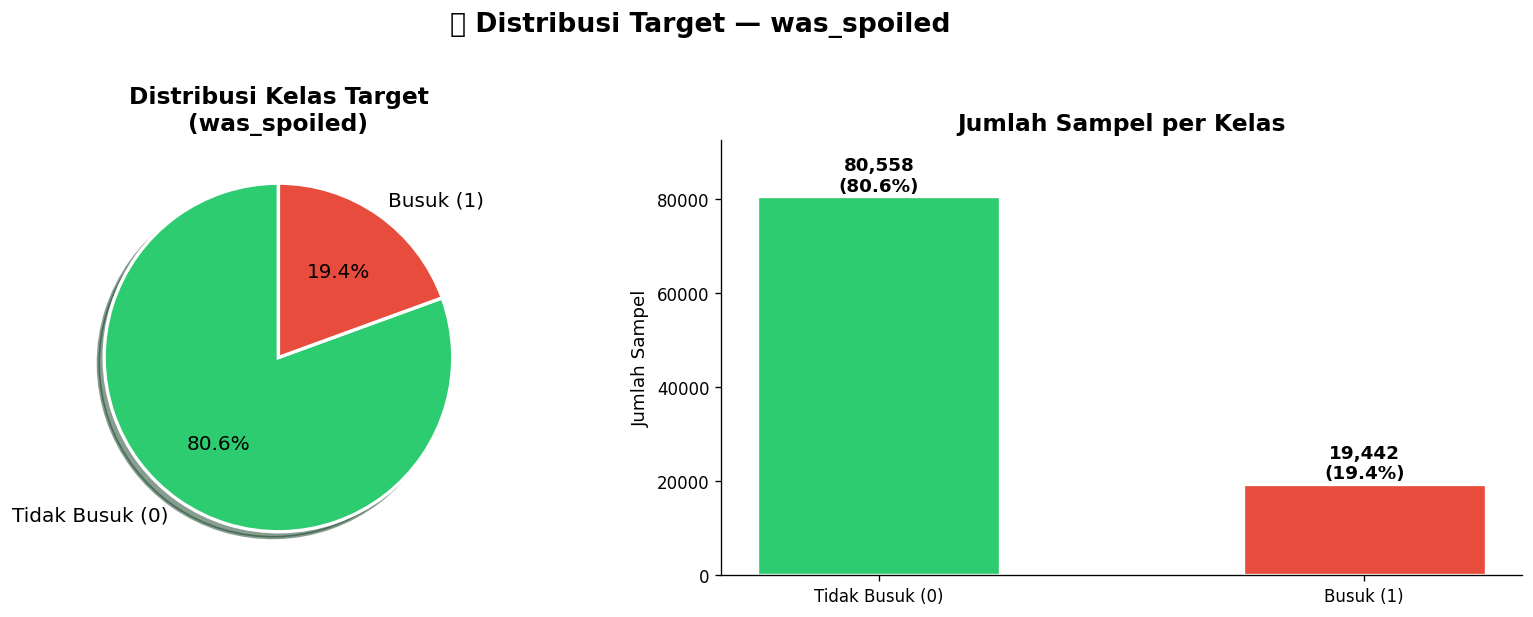

⚠️  Imbalance Ratio  : 1 : 4.14  →  Akan ditangani dengan SMOTE


In [ ]:
# ── 3.1 Distribusi Target ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#2ecc71', '#e74c3c']
labels = ['Tidak Busuk (0)', 'Busuk (1)']
values = df['was_spoiled'].value_counts().sort_index().values

# Pie chart
axes[0].pie(values, labels=labels, colors=colors, autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 12}, shadow=True,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Distribusi Kelas Target\n(was_spoiled)', fontsize=14, fontweight='bold')

# Bar chart dengan annotation
bars = axes[1].bar(labels, values, color=colors, edgecolor='white', linewidth=2, width=0.5)
for bar, val in zip(bars, values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
                 f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[1].set_title('Jumlah Sampel per Kelas', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Jumlah Sampel', fontsize=11)
axes[1].set_ylim(0, max(values) * 1.15)
axes[1].spines[['top', 'right']].set_visible(False)

plt.suptitle('📊 Distribusi Target — was_spoiled', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('01_target_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

print(f"⚠️  Imbalance Ratio  : 1 : {values[0]/values[1]:.2f}  →  Akan ditangani dengan SMOTE")


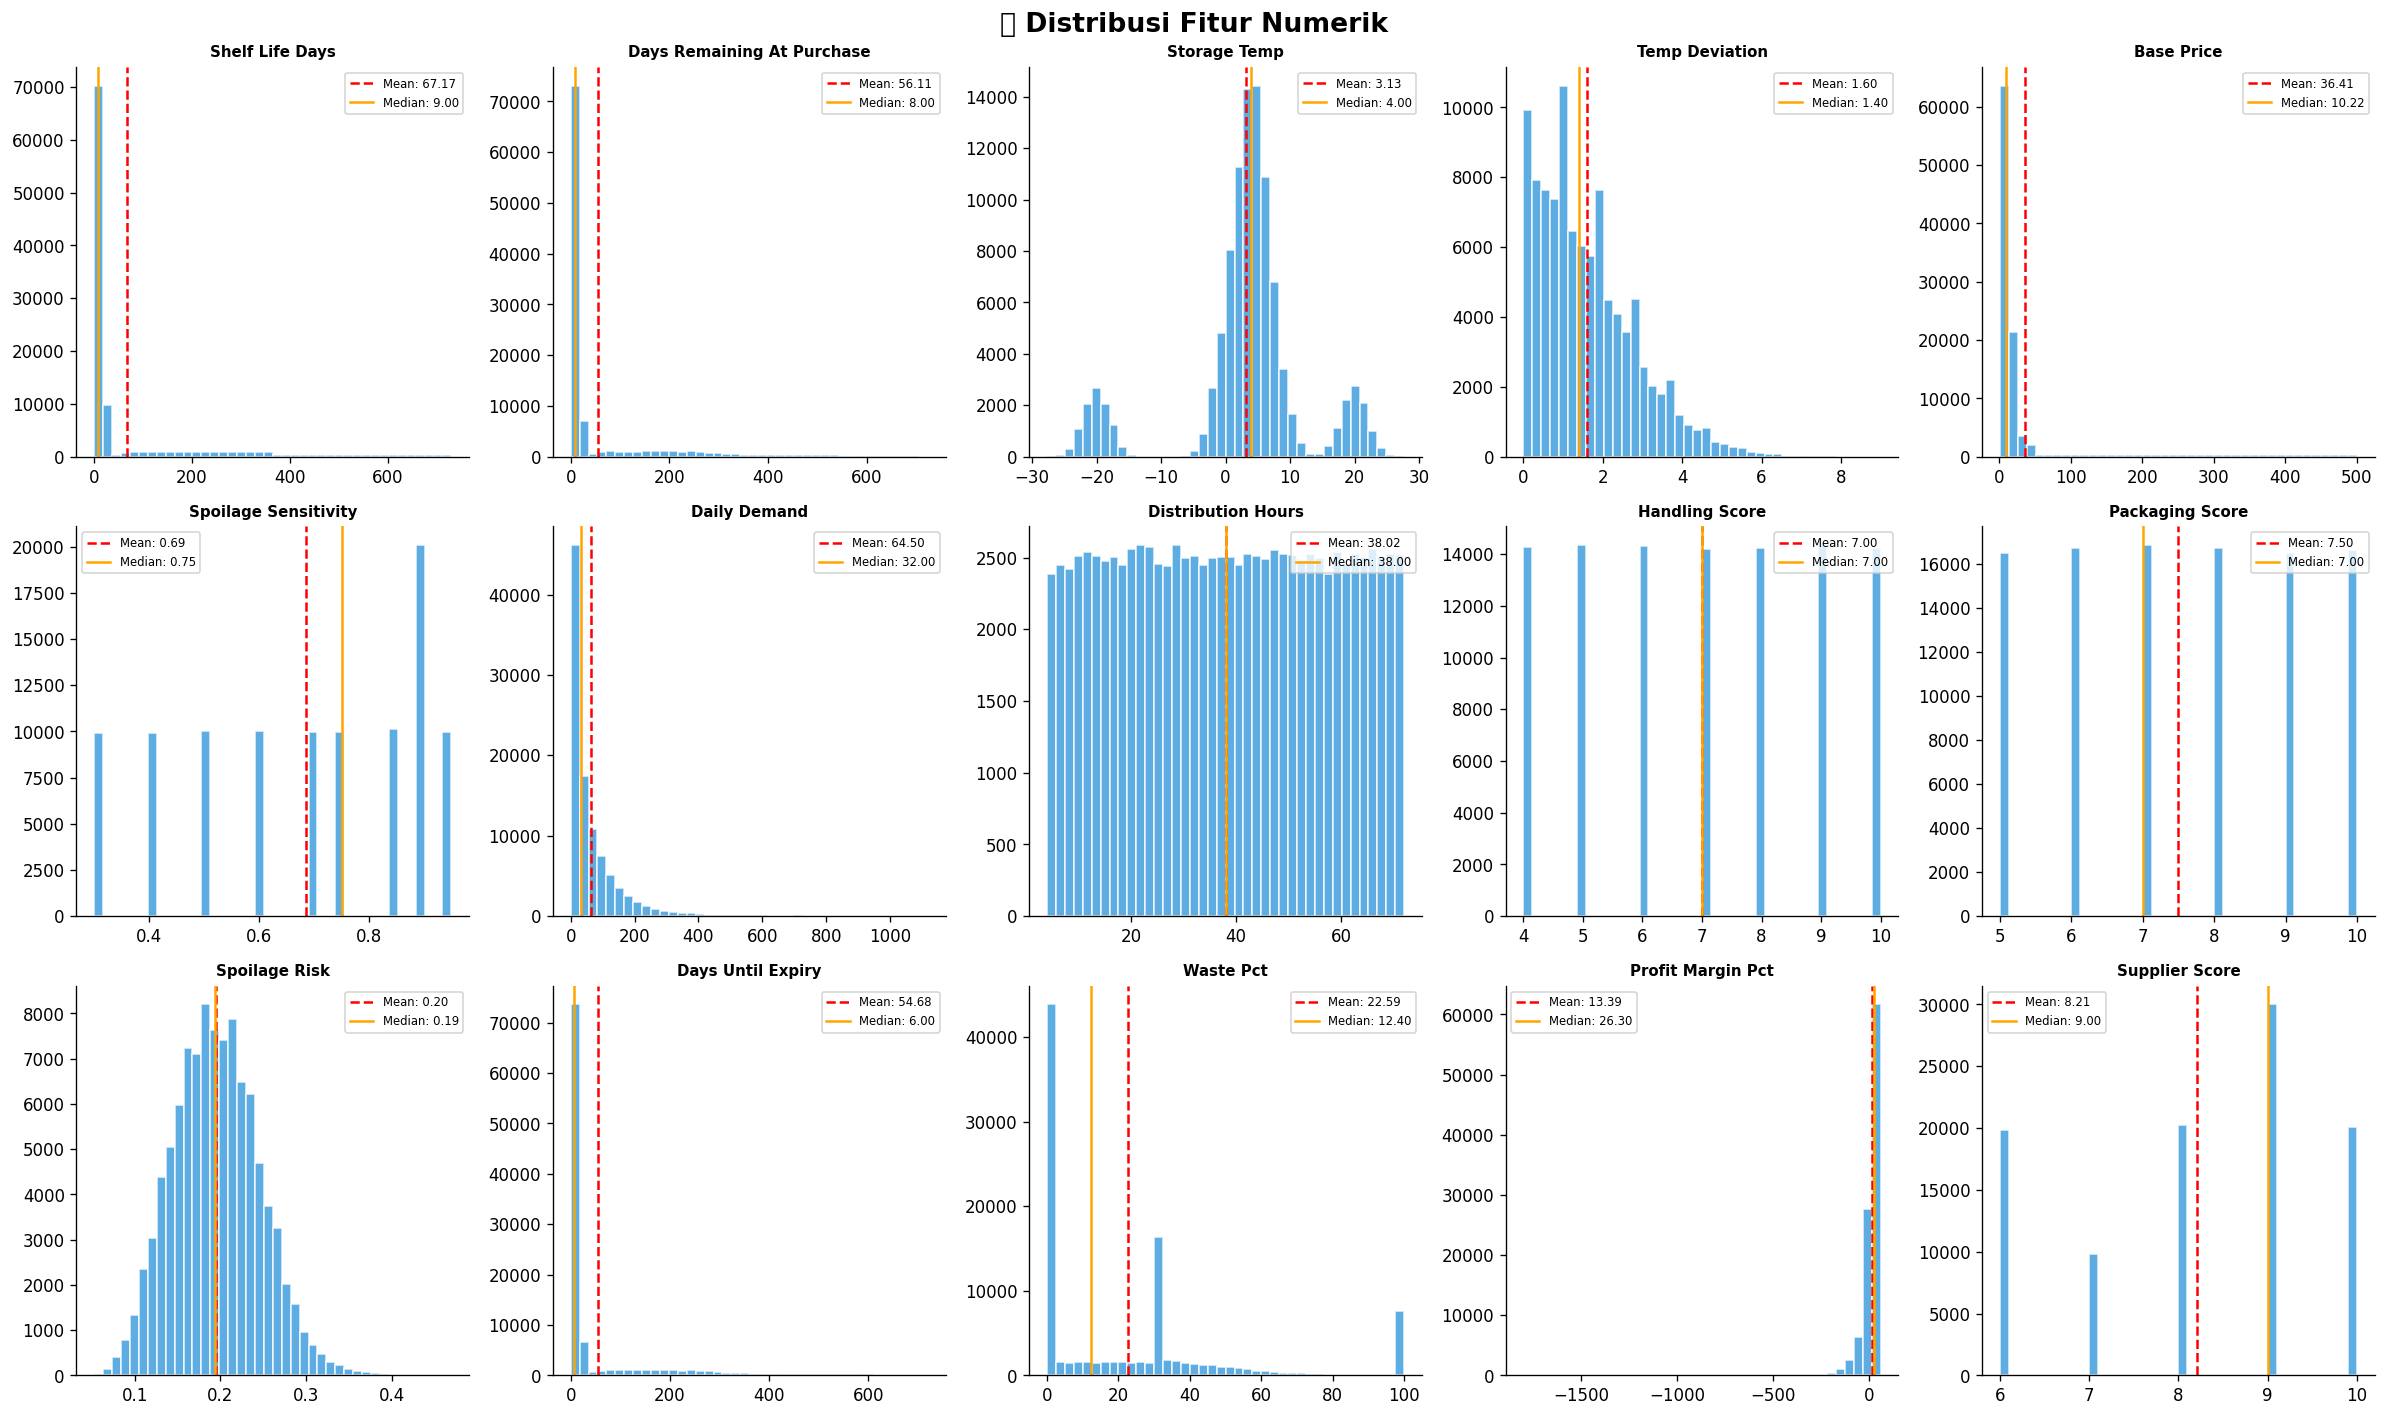

In [ ]:
# ── 3.2 Distribusi Fitur Numerik ─────────────────────────────────────────────
numeric_cols = [
    'shelf_life_days', 'days_remaining_at_purchase', 'storage_temp', 'temp_deviation',
    'base_price', 'spoilage_sensitivity', 'daily_demand', 'distribution_hours',
    'handling_score', 'packaging_score', 'spoilage_risk', 'days_until_expiry',
    'waste_pct', 'profit_margin_pct', 'supplier_score'
]

fig, axes = plt.subplots(3, 5, figsize=(20, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=40, color='#3498db', alpha=0.8, edgecolor='white')
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {df[col].mean():.2f}')
    axes[i].axvline(df[col].median(), color='orange', linestyle='-', linewidth=1.5, label=f'Median: {df[col].median():.2f}')
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=9, fontweight='bold')
    axes[i].legend(fontsize=7)
    axes[i].spines[['top', 'right']].set_visible(False)

plt.suptitle('📊 Distribusi Fitur Numerik', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('02_feature_distributions.png', bbox_inches='tight', dpi=150)
plt.show()


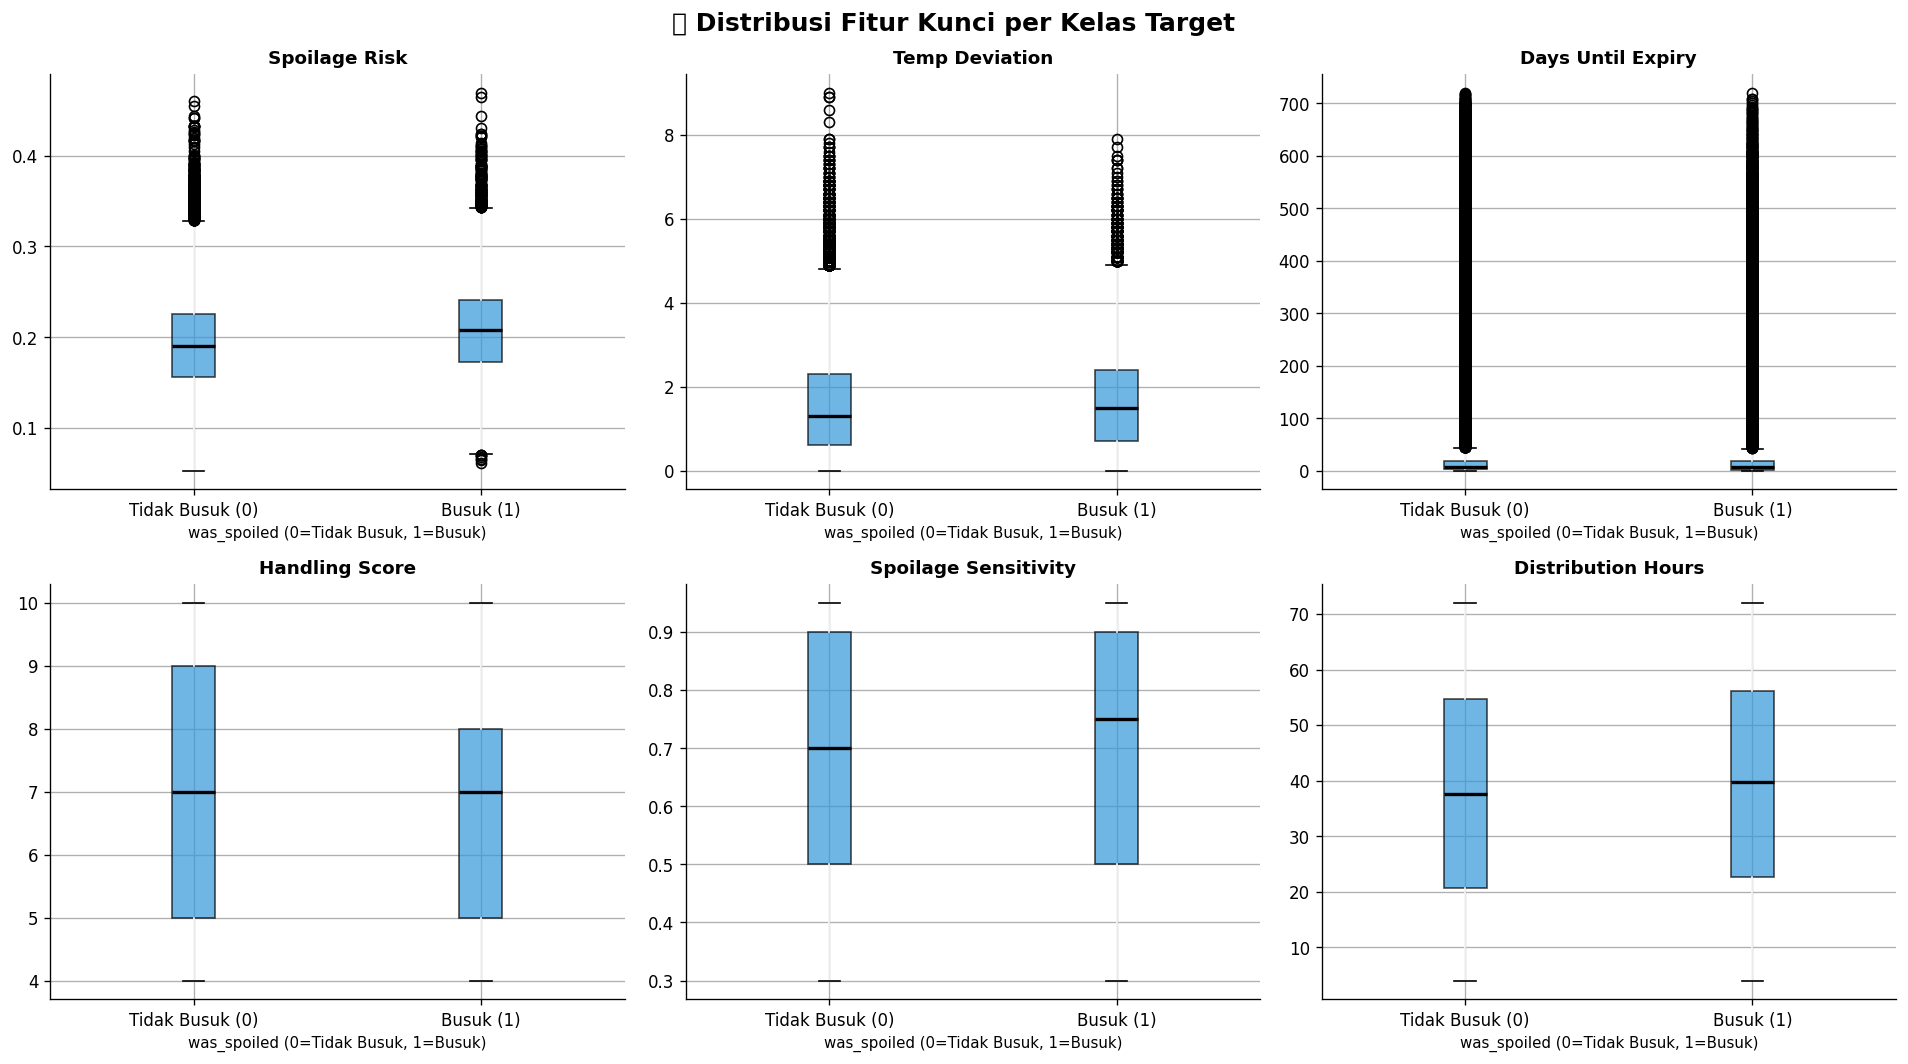

In [ ]:
# ── 3.3 Boxplot: Fitur vs Target ─────────────────────────────────────────────
key_features = ['spoilage_risk', 'temp_deviation', 'days_until_expiry',
                'handling_score', 'spoilage_sensitivity', 'distribution_hours']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
palette = {0: '#2ecc71', 1: '#e74c3c'}

for i, col in enumerate(key_features):
    df.boxplot(column=col, by='was_spoiled', ax=axes[i],
               patch_artist=True,
               boxprops=dict(facecolor='#3498db', alpha=0.7),
               medianprops=dict(color='black', linewidth=2))
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=11, fontweight='bold')
    axes[i].set_xlabel('was_spoiled (0=Tidak Busuk, 1=Busuk)', fontsize=9)
    axes[i].set_xticklabels(['Tidak Busuk (0)', 'Busuk (1)'])
    axes[i].spines[['top', 'right']].set_visible(False)

plt.suptitle('📦 Distribusi Fitur Kunci per Kelas Target', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('03_boxplots.png', bbox_inches='tight', dpi=150)
plt.show()


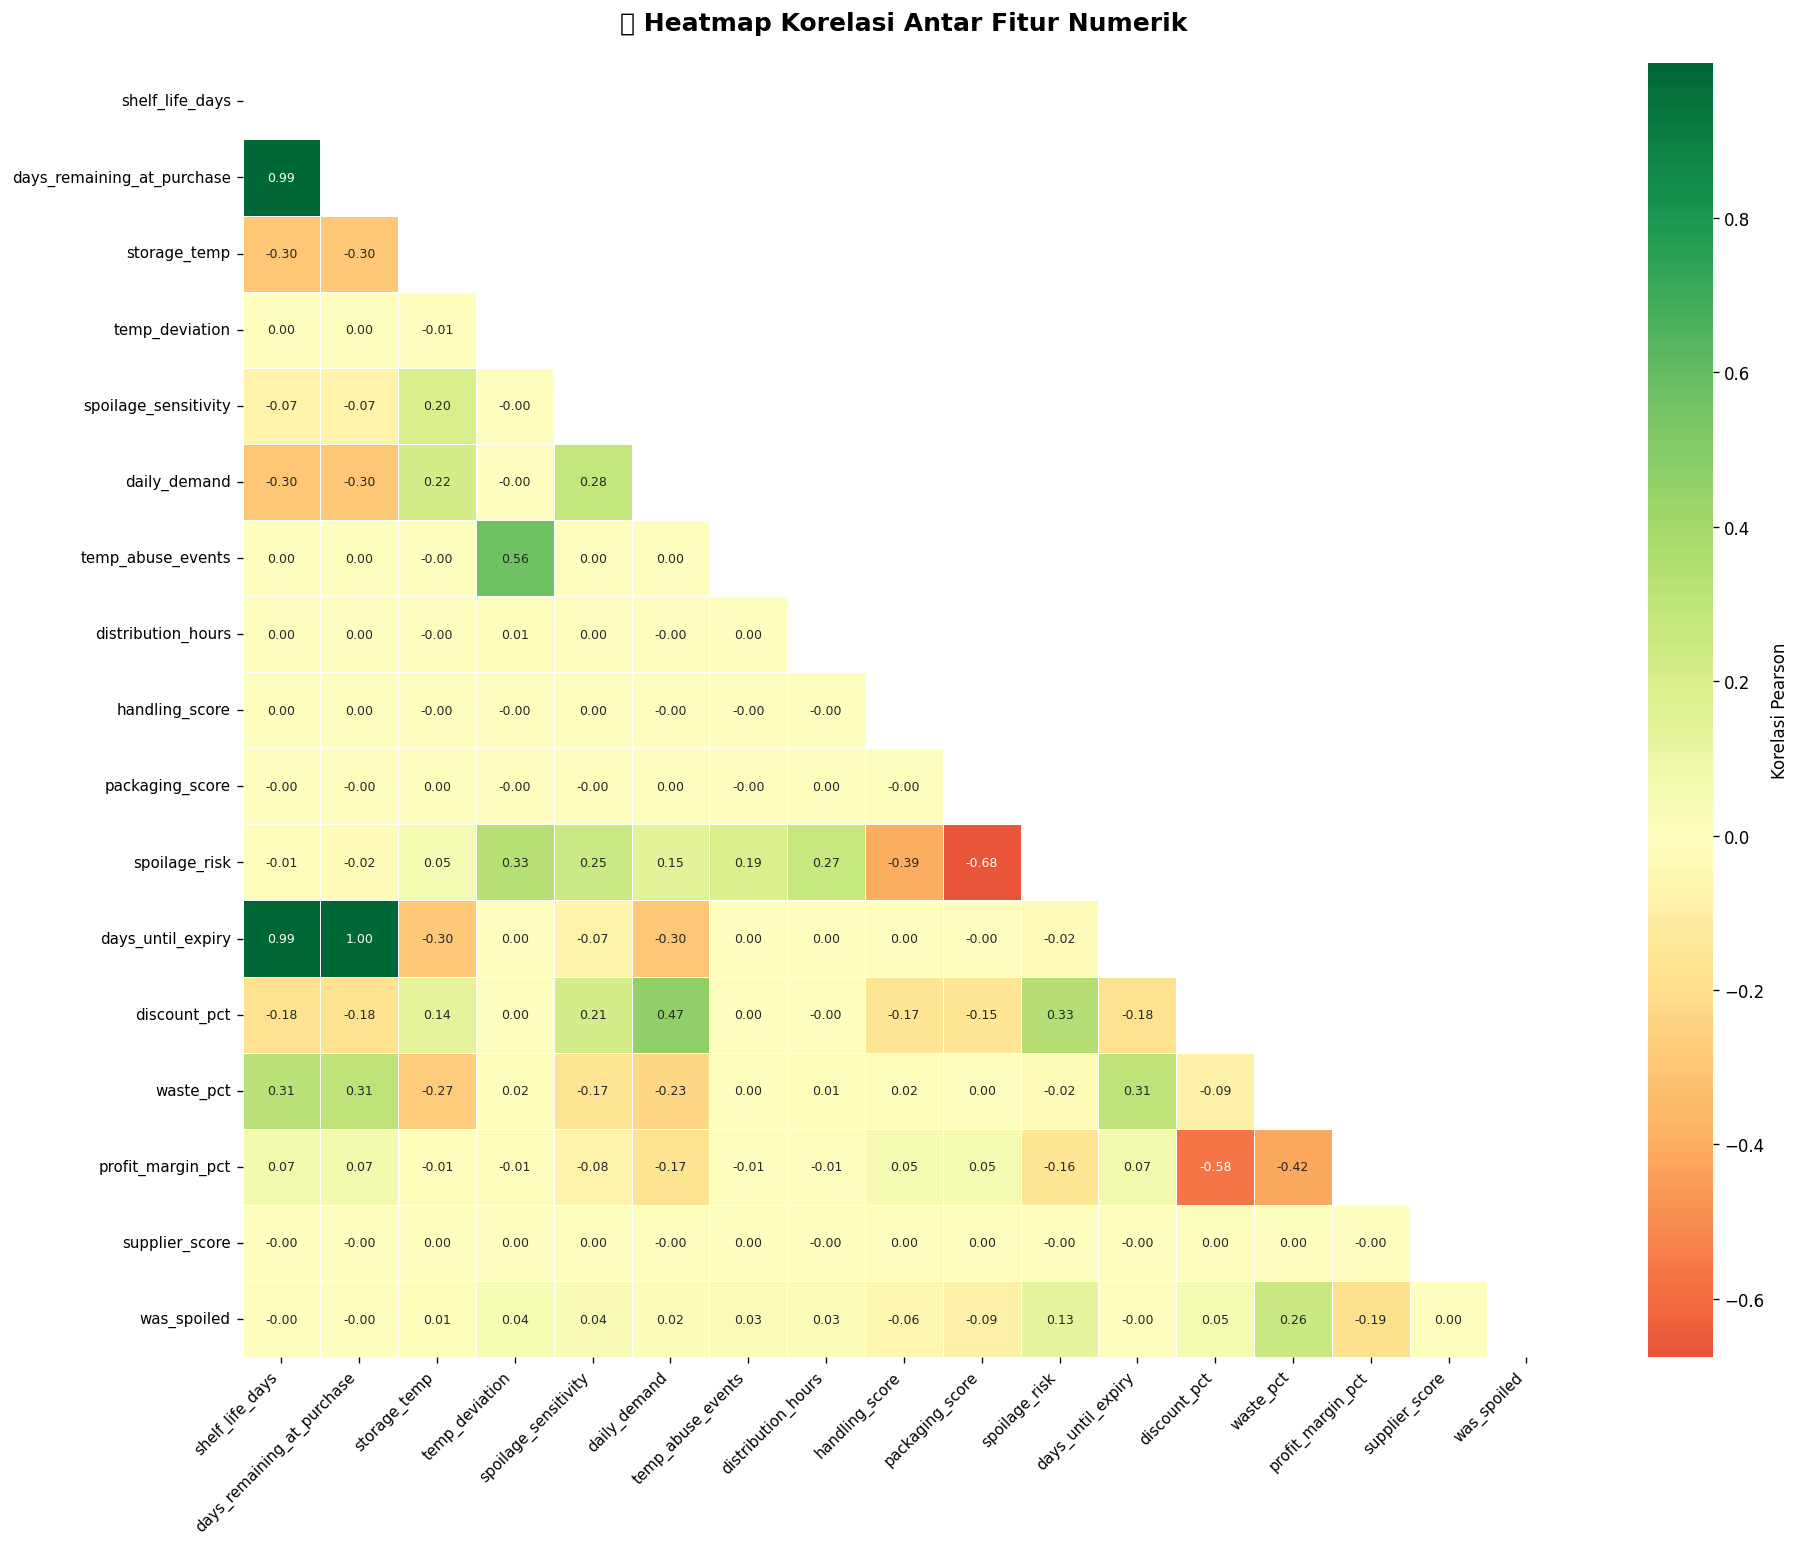


=== Top 10 Fitur Berkorelasi dengan Target (was_spoiled) ===
  waste_pct                           +0.2641
  profit_margin_pct                   -0.1888
  spoilage_risk                       +0.1308
  packaging_score                     -0.0885
  handling_score                      -0.0563
  discount_pct                        +0.0466
  temp_deviation                      +0.0427
  spoilage_sensitivity                +0.0370
  distribution_hours                  +0.0288
  temp_abuse_events                   +0.0287


In [ ]:
# ── 3.4 Heatmap Korelasi ─────────────────────────────────────────────────────
corr_cols = [
    'shelf_life_days', 'days_remaining_at_purchase', 'storage_temp', 'temp_deviation',
    'spoilage_sensitivity', 'daily_demand', 'temp_abuse_events', 'distribution_hours',
    'handling_score', 'packaging_score', 'spoilage_risk', 'days_until_expiry',
    'discount_pct', 'waste_pct', 'profit_margin_pct', 'supplier_score', 'was_spoiled'
]
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
heatmap = sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', ax=ax,
                       cmap='RdYlGn', center=0, linewidths=0.5,
                       annot_kws={'size': 7.5},
                       cbar_kws={'label': 'Korelasi Pearson'})
ax.set_title('🔥 Heatmap Korelasi Antar Fitur Numerik', fontsize=15, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('04_correlation_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()

print("\n=== Top 10 Fitur Berkorelasi dengan Target (was_spoiled) ===")
target_corr = corr_matrix['was_spoiled'].drop('was_spoiled').abs().sort_values(ascending=False)
for feat, val in target_corr.head(10).items():
    sign = "+" if corr_matrix.loc[feat, 'was_spoiled'] > 0 else "-"
    print(f"  {feat:<35} {sign}{val:.4f}")


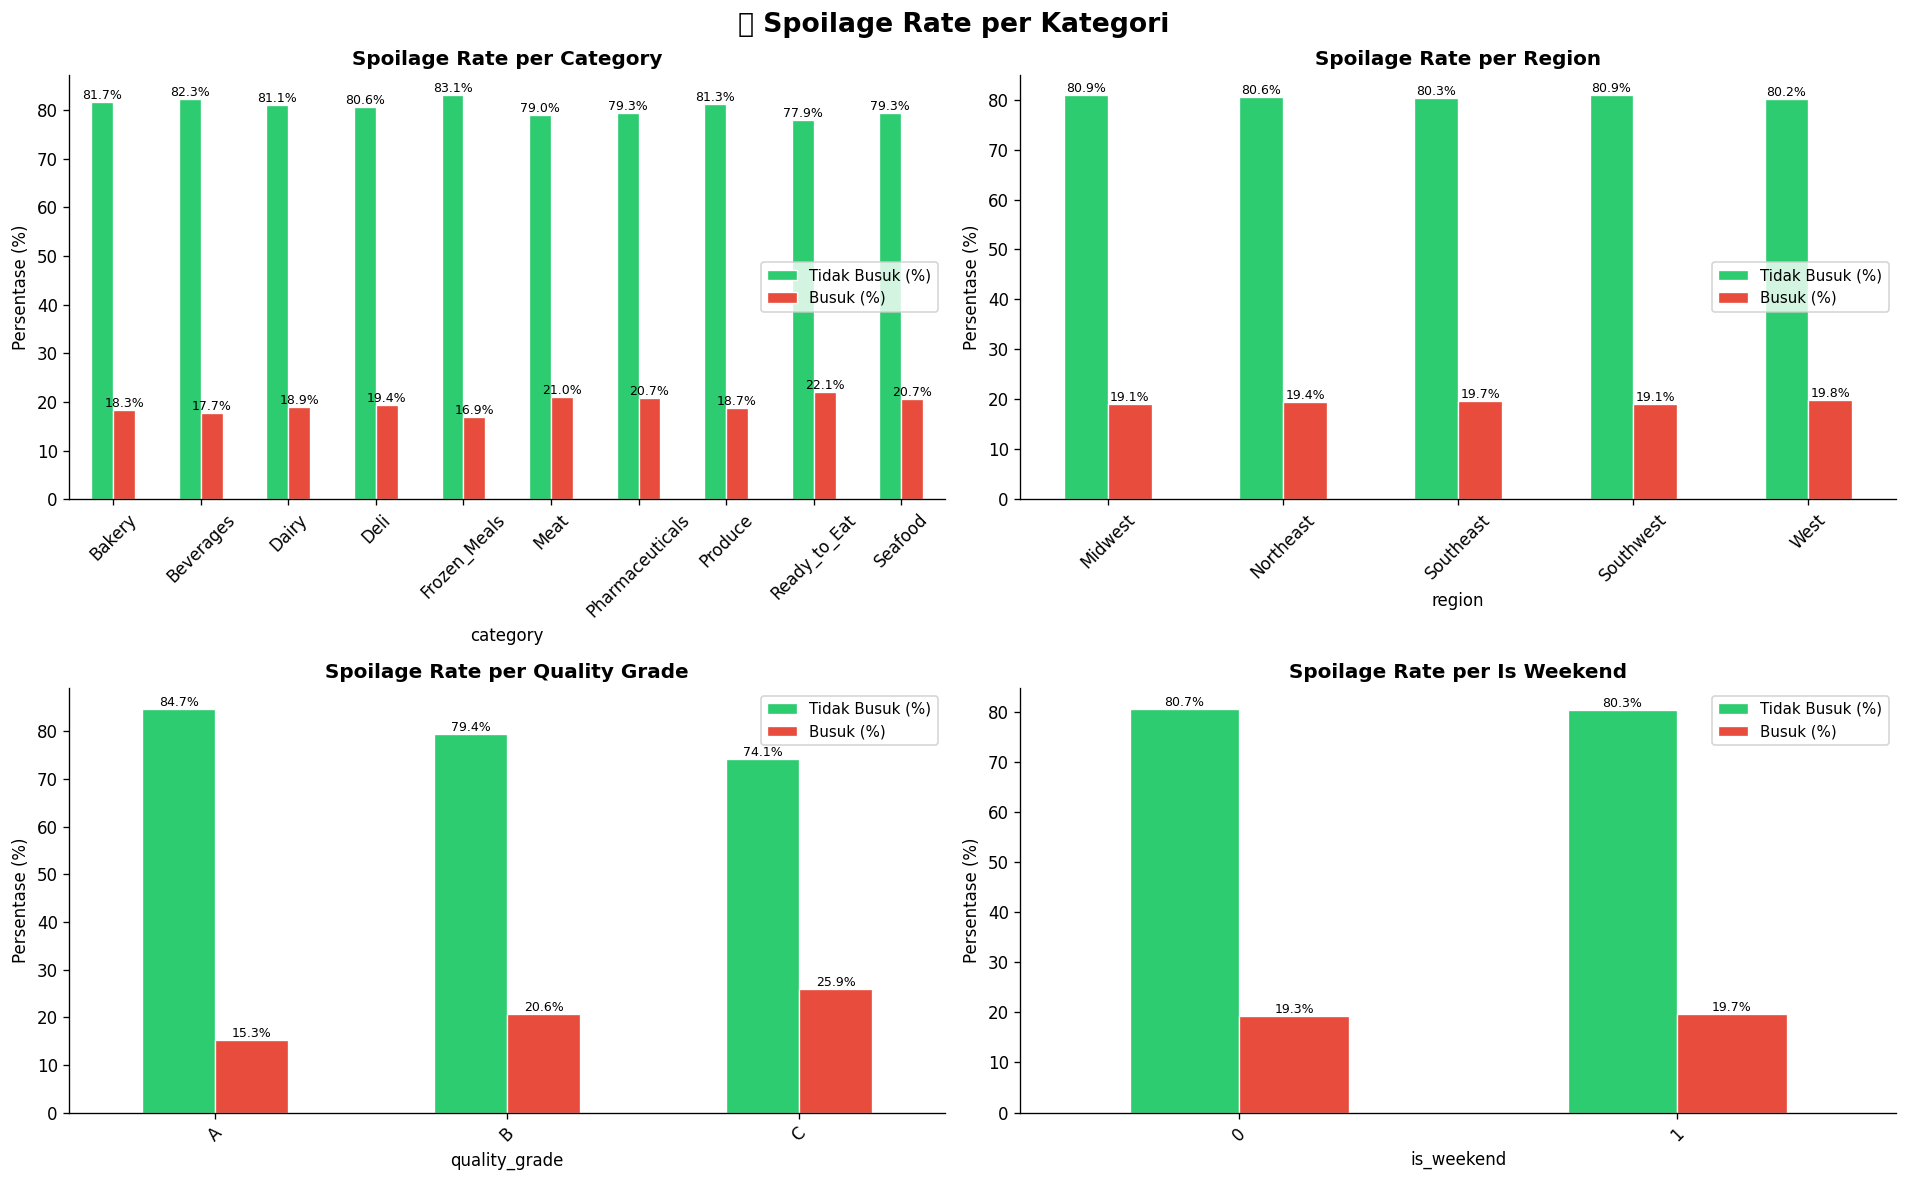

In [ ]:
# ── 3.5 Analisis Kategorikal ─────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

cat_cols = ['category', 'region', 'quality_grade', 'is_weekend']

for ax, col in zip(axes.flatten(), cat_cols):
    ct = pd.crosstab(df[col], df['was_spoiled'], normalize='index') * 100
    ct.columns = ['Tidak Busuk (%)', 'Busuk (%)']
    ct.plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c'],
            edgecolor='white', linewidth=0.8, rot=45)
    ax.set_title(f'Spoilage Rate per {col.replace("_"," ").title()}',
                 fontsize=12, fontweight='bold')
    ax.set_ylabel('Persentase (%)', fontsize=10)
    ax.legend(fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)
    for p in ax.patches:
        if p.get_height() > 2:
            ax.annotate(f'{p.get_height():.1f}%',
                        (p.get_x() + p.get_width()/2., p.get_height()),
                        ha='center', va='bottom', fontsize=7.5)

plt.suptitle('📈 Spoilage Rate per Kategori', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('05_categorical_analysis.png', bbox_inches='tight', dpi=150)
plt.show()


## 4. 🛠️ Preprocessing & Feature Engineering <a id='4'></a>

### Langkah-langkah:
1. **Encoding** fitur kategorikal → Label Encoding
2. **Feature Engineering** → fitur baru yang lebih informatif
3. **Pemisahan fitur dan target**
4. **Train-Test Split** (80:20, stratified)
5. **SMOTE** untuk menangani class imbalance


In [ ]:
# ── 4.1 Feature Engineering ─────────────────────────────────────────────────
df_ml = df.copy()

# Drop kolom identifier / leakage
drop_cols = ['record_id', 'product_id', 'product_name', 'store_id', 'supplier_id',
             'transaction_date', 'expiration_date',
             # leakage columns (dihitung setelah spoilage terjadi)
             'units_wasted', 'waste_pct', 'waste_cost']
df_ml.drop(columns=[c for c in drop_cols if c in df_ml.columns], inplace=True)

# Feature Engineering
df_ml['temp_risk_score']      = df_ml['storage_temp'] * df_ml['temp_deviation']
df_ml['quality_handling']     = df_ml['handling_score'] * df_ml['packaging_score']
df_ml['price_ratio']          = df_ml['base_price'] / (df_ml['cost_price'] + 1e-6)
df_ml['demand_pressure']      = df_ml['daily_demand'] / (df_ml['initial_quantity'] + 1e-6)
df_ml['shelf_urgency']        = 1 / (df_ml['days_until_expiry'] + 1)
df_ml['temp_abuse_rate']      = df_ml['temp_abuse_events'] / (df_ml['shelf_life_days'] + 1)
df_ml['supplier_quality']     = df_ml['supplier_score'] * df_ml['handling_score']
df_ml['sensitivity_exposure'] = df_ml['spoilage_sensitivity'] * df_ml['temp_deviation']

print("✅ Feature Engineering selesai! Fitur baru:")
new_feats = ['temp_risk_score','quality_handling','price_ratio','demand_pressure',
             'shelf_urgency','temp_abuse_rate','supplier_quality','sensitivity_exposure']
for f in new_feats:
    print(f"  + {f}")
print(f"\nTotal fitur setelah engineering: {df_ml.shape[1] - 1}")


✅ Feature Engineering selesai! Fitur baru:
  + temp_risk_score
  + quality_handling
  + price_ratio
  + demand_pressure
  + shelf_urgency
  + temp_abuse_rate
  + supplier_quality
  + sensitivity_exposure

Total fitur setelah engineering: 39


In [ ]:
# ── 4.2 Encoding ─────────────────────────────────────────────────────────────
cat_cols = df_ml.select_dtypes(include='object').columns.tolist()
print(f"Kolom kategorikal: {cat_cols}")

le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    df_ml[col] = le.fit_transform(df_ml[col].astype(str))
    le_dict[col] = le

print("✅ Label Encoding selesai!")

# ── 4.3 Train-Test Split ─────────────────────────────────────────────────────
X = df_ml.drop(columns=['was_spoiled'])
y = df_ml['was_spoiled']

FEATURE_NAMES = X.columns.tolist()
print(f"\nJumlah fitur final: {len(FEATURE_NAMES)}")
print(f"Distribusi target: {Counter(y)}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain size : {X_train.shape[0]:,} ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Test  size : {X_test.shape[0]:,}  ({X_test.shape[0]/len(X)*100:.0f}%)")


Kolom kategorikal: ['category', 'region', 'quality_grade']
✅ Label Encoding selesai!

Jumlah fitur final: 39
Distribusi target: Counter({0: 80558, 1: 19442})

Train size : 80,000 (80%)
Test  size : 20,000  (20%)


Sebelum SMOTE: Counter({0: 64446, 1: 15554})
Setelah SMOTE : Counter({0: 64446, 1: 64446})

✅ Dataset training seimbang: 128,892 sampel


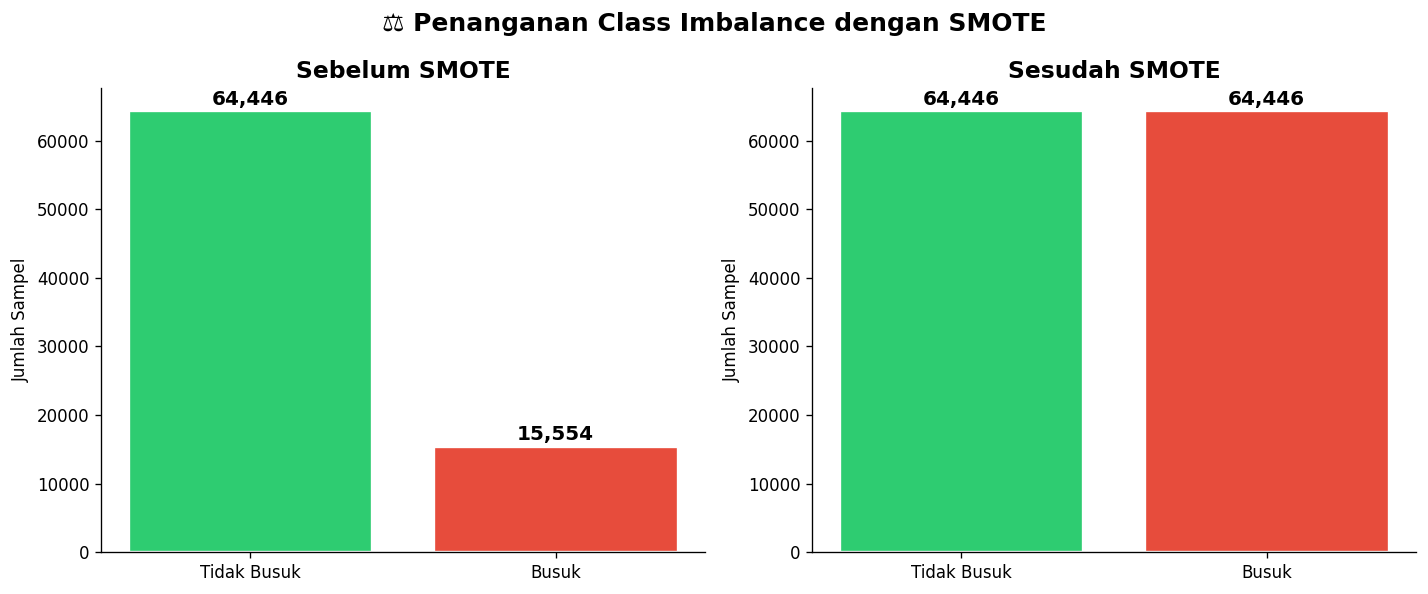

In [ ]:
# ── 4.4 SMOTE — Tangani Class Imbalance ─────────────────────────────────────
print("Sebelum SMOTE:", Counter(y_train))

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Setelah SMOTE :", Counter(y_train_sm))
print(f"\n✅ Dataset training seimbang: {X_train_sm.shape[0]:,} sampel")

# Visualisasi sebelum vs sesudah SMOTE
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
before = pd.Series(y_train).value_counts().sort_index()
after  = pd.Series(y_train_sm).value_counts().sort_index()

for ax, data, title in zip(axes, [before, after], ['Sebelum SMOTE', 'Sesudah SMOTE']):
    colors = ['#2ecc71', '#e74c3c']
    bars = ax.bar(['Tidak Busuk', 'Busuk'], data.values, color=colors, edgecolor='white', linewidth=2)
    for bar, v in zip(bars, data.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+200,
                f'{v:,}', ha='center', va='bottom', fontweight='bold', fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_ylabel('Jumlah Sampel')
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('⚖️ Penanganan Class Imbalance dengan SMOTE', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('06_smote.png', bbox_inches='tight', dpi=150)
plt.show()


## 5. 📚 Teori Algoritma — XGBoost <a id='5'></a>

### Apa itu XGBoost?
**XGBoost** (eXtreme Gradient Boosting) adalah implementasi optimized dari algoritma **Gradient Boosted Decision Trees (GBDT)** yang dikembangkan oleh *Tianqi Chen* (2016). XGBoost menjadi sangat populer karena:
- 🏆 Memenangkan banyak kompetisi Kaggle
- ⚡ Sangat cepat berkat paralelisasi
- 🛡️ Regularisasi built-in (L1 & L2) untuk mencegah overfitting

### Cara Kerja (Boosting)
XGBoost membangun model secara **sekuensial** (additive). Setiap tree baru memperbaiki error dari tree sebelumnya:

$$F_m(x) = F_{m-1}(x) + \eta \cdot h_m(x)$$

Di mana:
- $F_m(x)$ = model ke-m
- $\eta$ = learning rate (mengontrol kontribusi tiap tree)
- $h_m(x)$ = tree baru yang memperbaiki residual

### Objective Function
$$\mathcal{L} = \sum_{i=1}^{n} l(y_i, \hat{y}_i) + \sum_{k=1}^{K} \Omega(f_k)$$

$$\Omega(f) = \gamma T + \frac{1}{2}\lambda \|w\|^2$$

Di mana:
- $l$ = loss function (log-loss untuk klasifikasi)
- $\Omega$ = regularization term
- $T$ = jumlah leaf pada tree
- $\lambda, \gamma$ = hyperparameter regularisasi

### Keunggulan XGBoost
| Fitur | Keterangan |
|-------|------------|
| **Regularisasi L1 & L2** | Mencegah overfitting lebih efektif dari GBDT biasa |
| **Tree Pruning** | Menggunakan depth-first pruning |
| **Penanganan Missing Value** | Otomatis menemukan arah terbaik untuk missing data |
| **Paralelisasi** | Split tree diparalelkan untuk kecepatan |
| **Cache Awareness** | Optimasi akses memori untuk data besar |

### Hyperparameter Penting
| Parameter | Fungsi |
|-----------|--------|
| `n_estimators` | Jumlah trees |
| `max_depth` | Kedalaman maksimum tree |
| `learning_rate` (eta) | Kecepatan belajar — semakin kecil semakin akurat tapi lambat |
| `subsample` | Proporsi data yang digunakan per tree |
| `colsample_bytree` | Proporsi fitur per tree |
| `reg_alpha` | L1 regularization |
| `reg_lambda` | L2 regularization |
| `scale_pos_weight` | Bobot kelas positif (berguna untuk imbalanced data) |


## 6. 📚 Teori Algoritma — CatBoost <a id='6'></a>

### Apa itu CatBoost?
**CatBoost** (Categorical Boosting) dikembangkan oleh **Yandex** (2018). Inovasi utamanya adalah penanganan **fitur kategorikal secara native** tanpa perlu encoding manual, serta teknik **Ordered Boosting** untuk menghindari target leakage.

### Inovasi Utama: Ordered Target Statistics
Masalah pada GBDT klasik: saat menghitung **target encoding** untuk fitur kategorikal, model dapat "melihat" label dari data yang sedang diproses → **target leakage**.

CatBoost memecahkan ini dengan **Ordered Target Statistics**:

$$\hat{x}_i^k = \frac{\sum_{j \in D_{i-1}, x_j^k = x_i^k} y_j + a \cdot p}{\sum_{j \in D_{i-1}, x_j^k = x_i^k} 1 + a}$$

Di mana $D_{i-1}$ adalah **subset data sebelum sampel ke-i** (permutasi acak) — sehingga tidak ada leakage.

### Ordered Boosting
CatBoost menggunakan permutasi acak dari data training:
1. Buat urutan acak data: $\sigma = (\sigma_1, ..., \sigma_n)$
2. Untuk sampel ke-$i$, hanya gunakan $\{\sigma_1, ..., \sigma_{i-1}\}$ untuk menghitung residual
3. Ini memastikan model **tidak overfitting** pada data training

### Symmetric (Oblivious) Trees
CatBoost menggunakan **oblivious decision trees** — semua node pada level yang sama menggunakan **split yang sama**:
- Lebih cepat dalam inferensi
- Bertindak sebagai regularisasi implisit
- Konsisten dan dapat diprediksi

### Perbandingan XGBoost vs CatBoost
| Aspek | XGBoost | CatBoost |
|-------|---------|----------|
| **Fitur Kategorikal** | Butuh encoding manual | Native, otomatis |
| **Overfitting** | Regularisasi L1/L2 | Ordered Boosting |
| **Tree Type** | Asymmetric (CART) | Symmetric (Oblivious) |
| **Kecepatan Training** | Cepat (paralel) | Lebih lambat tapi lebih akurat |
| **Kecepatan Inferensi** | Cepat | Sangat cepat (symmetric trees) |
| **Tuning** | Butuh banyak tuning | Relatif robust dengan default |
| **Memory** | Lebih hemat | Lebih boros |


## 7. 🚀 Training Model XGBoost <a id='7'></a>

In [ ]:
# ── Hyperparameter XGBoost ───────────────────────────────────────────────────
xgb_params = {
    'n_estimators'     : 500,
    'max_depth'        : 6,
    'learning_rate'    : 0.05,
    'subsample'        : 0.8,
    'colsample_bytree' : 0.8,
    'reg_alpha'        : 0.1,       # L1
    'reg_lambda'       : 1.0,       # L2
    'min_child_weight' : 3,
    'gamma'            : 0.1,
    'scale_pos_weight' : 1,         # sudah pakai SMOTE
    'eval_metric'      : 'logloss',
    'use_label_encoder': False,
    'random_state'     : 42,
    'n_jobs'           : -1,
    'tree_method'      : 'hist',    # lebih cepat untuk data besar
    'early_stopping_rounds': 30
}

# Training
print("🚀 Memulai training XGBoost...")
xgb_model = XGBClassifier(**xgb_params)

start = time.time()
xgb_model.fit(
    X_train_sm, y_train_sm,
    eval_set=[(X_test, y_test)],
    verbose=100
)
xgb_time = time.time() - start

print(f"\n✅ XGBoost Training selesai dalam {xgb_time:.2f} detik")
print(f"   Best iteration : {xgb_model.best_iteration}")


🚀 Memulai training XGBoost...
[0]	validation_0-logloss:0.67089
[100]	validation_0-logloss:0.29793
[200]	validation_0-logloss:0.22852
[300]	validation_0-logloss:0.20319
[400]	validation_0-logloss:0.19148
[499]	validation_0-logloss:0.18538

✅ XGBoost Training selesai dalam 40.20 detik
   Best iteration : 499


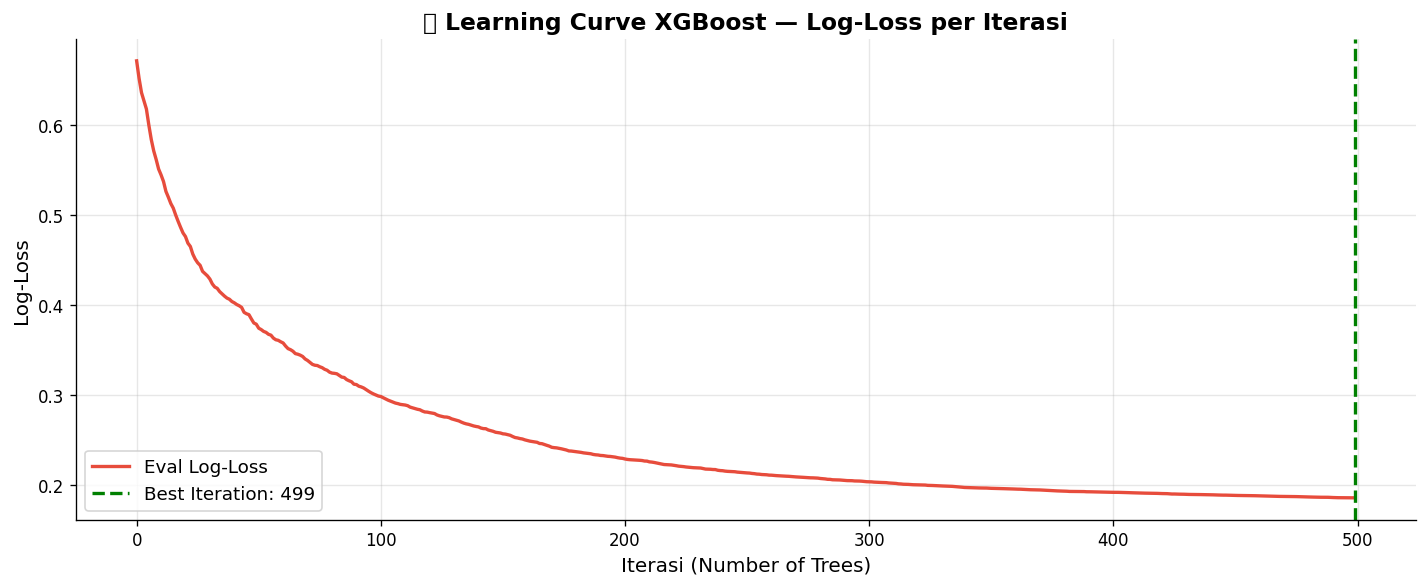

In [ ]:
# ── Learning Curve XGBoost ───────────────────────────────────────────────────
results = xgb_model.evals_result()
train_loss = results['validation_0']['logloss']  # pakai eval set sebagai proxy

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(train_loss, color='#e74c3c', linewidth=2, label='Eval Log-Loss')
ax.axvline(xgb_model.best_iteration, color='green', linestyle='--', linewidth=2,
           label=f'Best Iteration: {xgb_model.best_iteration}')
ax.set_xlabel('Iterasi (Number of Trees)', fontsize=12)
ax.set_ylabel('Log-Loss', fontsize=12)
ax.set_title('📉 Learning Curve XGBoost — Log-Loss per Iterasi', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('07_xgb_learning_curve.png', bbox_inches='tight', dpi=150)
plt.show()


## 8. 🐱 Training Model CatBoost <a id='8'></a>

In [ ]:
# ── Hyperparameter CatBoost ─────────────────────────────────────────────────
cat_params = {
    'iterations'        : 500,
    'depth'             : 6,
    'learning_rate'     : 0.05,
    'l2_leaf_reg'       : 3.0,
    'subsample'         : 0.8,
    'colsample_bylevel' : 0.8,
    'min_data_in_leaf'  : 20,
    'random_seed'       : 42,
    'eval_metric'       : 'Logloss',
    'od_type'           : 'Iter',   # early stopping
    'od_wait'           : 30,
    'verbose'           : 100,
    'thread_count'      : -1
}

# Training
print("🐱 Memulai training CatBoost...")
cat_model = CatBoostClassifier(**cat_params)

start = time.time()
cat_model.fit(
    X_train_sm, y_train_sm,
    eval_set=(X_test, y_test),
    use_best_model=True
)
cat_time = time.time() - start

print(f"\n✅ CatBoost Training selesai dalam {cat_time:.2f} detik")
print(f"   Best iteration : {cat_model.best_iteration_}")


🐱 Memulai training CatBoost...
0:	learn: 0.6336522	test: 0.6147501	best: 0.6147501 (0)	total: 123ms	remaining: 1m 1s
100:	learn: 0.2179474	test: 0.2872473	best: 0.2872473 (100)	total: 6.2s	remaining: 24.5s
200:	learn: 0.1711847	test: 0.2397286	best: 0.2397286 (200)	total: 10.8s	remaining: 16.1s
300:	learn: 0.1481539	test: 0.2154267	best: 0.2154267 (300)	total: 15.9s	remaining: 10.5s
400:	learn: 0.1358890	test: 0.2037407	best: 0.2037407 (400)	total: 21.4s	remaining: 5.29s
499:	learn: 0.1278396	test: 0.1969042	best: 0.1969042 (499)	total: 25.9s	remaining: 0us

bestTest = 0.1969042294
bestIteration = 499


✅ CatBoost Training selesai dalam 26.49 detik
   Best iteration : 499


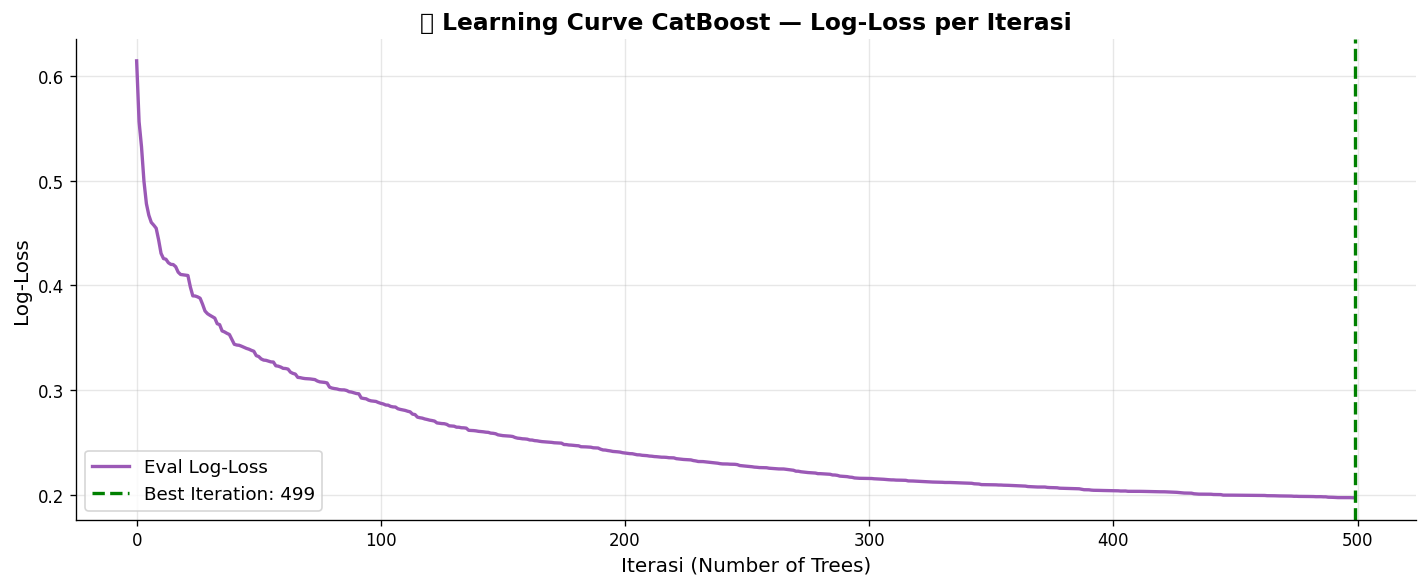

In [ ]:
# ── Learning Curve CatBoost ─────────────────────────────────────────────────
cat_evals = cat_model.get_evals_result()
cat_loss  = cat_evals['validation']['Logloss']

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(cat_loss, color='#9b59b6', linewidth=2, label='Eval Log-Loss')
ax.axvline(cat_model.best_iteration_, color='green', linestyle='--', linewidth=2,
           label=f'Best Iteration: {cat_model.best_iteration_}')
ax.set_xlabel('Iterasi (Number of Trees)', fontsize=12)
ax.set_ylabel('Log-Loss', fontsize=12)
ax.set_title('📉 Learning Curve CatBoost — Log-Loss per Iterasi', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('08_cat_learning_curve.png', bbox_inches='tight', dpi=150)
plt.show()


## 9. 📊 Evaluasi & Metrik Performa <a id='9'></a>

### Metrik yang Digunakan

| Metrik | Formula | Interpretasi |
|--------|---------|-------------|
| **Accuracy** | $\frac{TP+TN}{TP+TN+FP+FN}$ | Proporsi prediksi benar keseluruhan |
| **Precision** | $\frac{TP}{TP+FP}$ | Dari yang diprediksi busuk, berapa yang benar-benar busuk? |
| **Recall** | $\frac{TP}{TP+FN}$ | Dari yang benar-benar busuk, berapa yang berhasil terdeteksi? |
| **F1-Score** | $\frac{2 \cdot P \cdot R}{P+R}$ | Harmonic mean Precision & Recall |
| **AUC-ROC** | Area under ROC curve | Kemampuan diskriminasi model (semakin → 1, semakin baik) |
| **MCC** | $\frac{TP \cdot TN - FP \cdot FN}{\sqrt{(TP+FP)(TP+FN)(TN+FP)(TN+FN)}}$ | Metrik terbaik untuk imbalanced data |
| **Log-Loss** | $-\frac{1}{N}\sum y_i \log(\hat{p}_i)$ | Seberapa yakin model (semakin → 0, semakin baik) |

> **💡 Untuk kasus spoilage:** Recall lebih penting dari Precision.  
> Lebih baik salah mengira produk busuk (false alarm) daripada melewatkan produk busuk yang menyebabkan kerugian.


In [ ]:
# ── Prediksi ─────────────────────────────────────────────────────────────────
xgb_pred  = xgb_model.predict(X_test)
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]

cat_pred  = cat_model.predict(X_test).flatten()
cat_proba = cat_model.predict_proba(X_test)[:, 1]

# ── Hitung Metrik ─────────────────────────────────────────────────────────────
def get_metrics(y_true, y_pred, y_proba, model_name):
    return {
        'Model'         : model_name,
        'Accuracy'      : accuracy_score(y_true, y_pred),
        'Precision'     : precision_score(y_true, y_pred),
        'Recall'        : recall_score(y_true, y_pred),
        'F1-Score'      : f1_score(y_true, y_pred),
        'AUC-ROC'       : roc_auc_score(y_true, y_proba),
        'Avg Precision' : average_precision_score(y_true, y_proba),
        'MCC'           : matthews_corrcoef(y_true, y_pred),
        'Log-Loss'      : log_loss(y_true, y_proba)
    }

xgb_metrics = get_metrics(y_test, xgb_pred, xgb_proba, 'XGBoost')
cat_metrics = get_metrics(y_test, cat_pred, cat_proba, 'CatBoost')

metrics_df = pd.DataFrame([xgb_metrics, cat_metrics]).set_index('Model')
print("=" * 65)
print("           TABEL PERBANDINGAN METRIK EVALUASI")
print("=" * 65)
display(metrics_df.style
    .highlight_max(subset=metrics_df.columns[:-1], color='#abebc6')  # hijau = lebih baik (kecuali log-loss)
    .highlight_min(subset=['Log-Loss'], color='#abebc6')
    .format("{:.4f}"))


           TABEL PERBANDINGAN METRIK EVALUASI


,Accuracy,Precision,Recall,F1-Score,AUC-ROC,Avg Precision,MCC,Log-Loss
Model,,,,,,,,
XGBoost,0.9232,0.8534,0.7305,0.7871,0.9604,0.8878,0.7440,0.1854
CatBoost,0.9188,0.8264,0.7371,0.7792,0.9589,0.8821,0.7315,0.1969


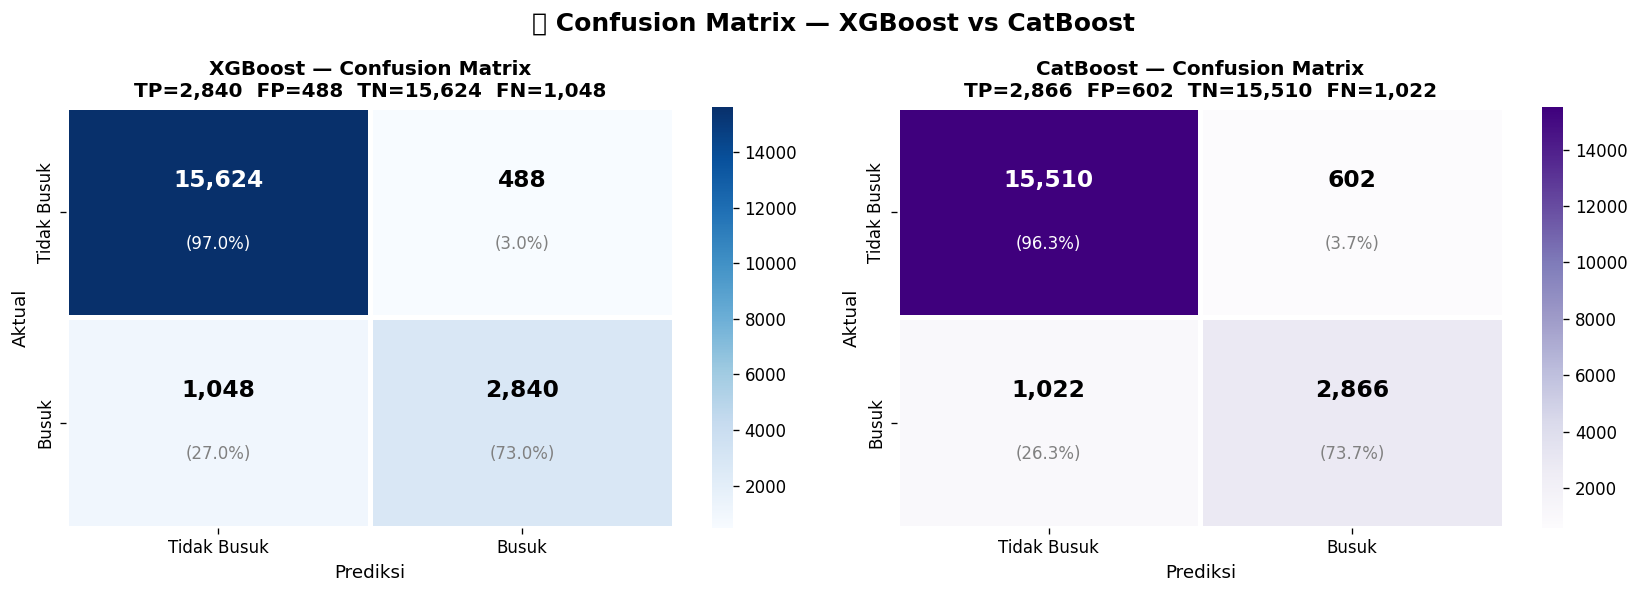

In [ ]:
# ── Confusion Matrix ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, pred, color) in zip(axes, [
    ('XGBoost',  xgb_pred, 'Blues'),
    ('CatBoost', cat_pred, 'Purples')
]):
    cm = confusion_matrix(y_test, pred)
    cm_pct = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis] * 100

    sns.heatmap(cm, annot=False, fmt='d', cmap=color, ax=ax,
                linewidths=2, linecolor='white',
                xticklabels=['Tidak Busuk', 'Busuk'],
                yticklabels=['Tidak Busuk', 'Busuk'])

    for i in range(2):
        for j in range(2):
            ax.text(j+0.5, i+0.35, f'{cm[i,j]:,}',
                    ha='center', va='center', fontsize=14, fontweight='bold',
                    color='white' if cm[i,j] > cm.max()/2 else 'black')
            ax.text(j+0.5, i+0.65, f'({cm_pct[i,j]:.1f}%)',
                    ha='center', va='center', fontsize=10,
                    color='white' if cm[i,j] > cm.max()/2 else 'gray')

    tn, fp, fn, tp = cm.ravel()
    ax.set_title(
        f'{name} — Confusion Matrix\n'
        f'TP={tp:,}  FP={fp:,}  TN={tn:,}  FN={fn:,}',
        fontsize=12, fontweight='bold'
    )
    ax.set_xlabel('Prediksi', fontsize=11)
    ax.set_ylabel('Aktual', fontsize=11)

plt.suptitle('🎯 Confusion Matrix — XGBoost vs CatBoost', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('09_confusion_matrix.png', bbox_inches='tight', dpi=150)
plt.show()


In [ ]:
# ── Classification Report ─────────────────────────────────────────────────────
print("=" * 55)
print("       CLASSIFICATION REPORT — XGBoost")
print("=" * 55)
print(classification_report(y_test, xgb_pred,
      target_names=['Tidak Busuk (0)', 'Busuk (1)']))

print("=" * 55)
print("       CLASSIFICATION REPORT — CatBoost")
print("=" * 55)
print(classification_report(y_test, cat_pred,
      target_names=['Tidak Busuk (0)', 'Busuk (1)']))


       CLASSIFICATION REPORT — XGBoost
                 precision    recall  f1-score   support

Tidak Busuk (0)       0.94      0.97      0.95     16112
      Busuk (1)       0.85      0.73      0.79      3888

       accuracy                           0.92     20000
      macro avg       0.90      0.85      0.87     20000
   weighted avg       0.92      0.92      0.92     20000

       CLASSIFICATION REPORT — CatBoost
                 precision    recall  f1-score   support

Tidak Busuk (0)       0.94      0.96      0.95     16112
      Busuk (1)       0.83      0.74      0.78      3888

       accuracy                           0.92     20000
      macro avg       0.88      0.85      0.86     20000
   weighted avg       0.92      0.92      0.92     20000



## 10. 📊 Visualisasi Perbandingan Komprehensif <a id='10'></a>

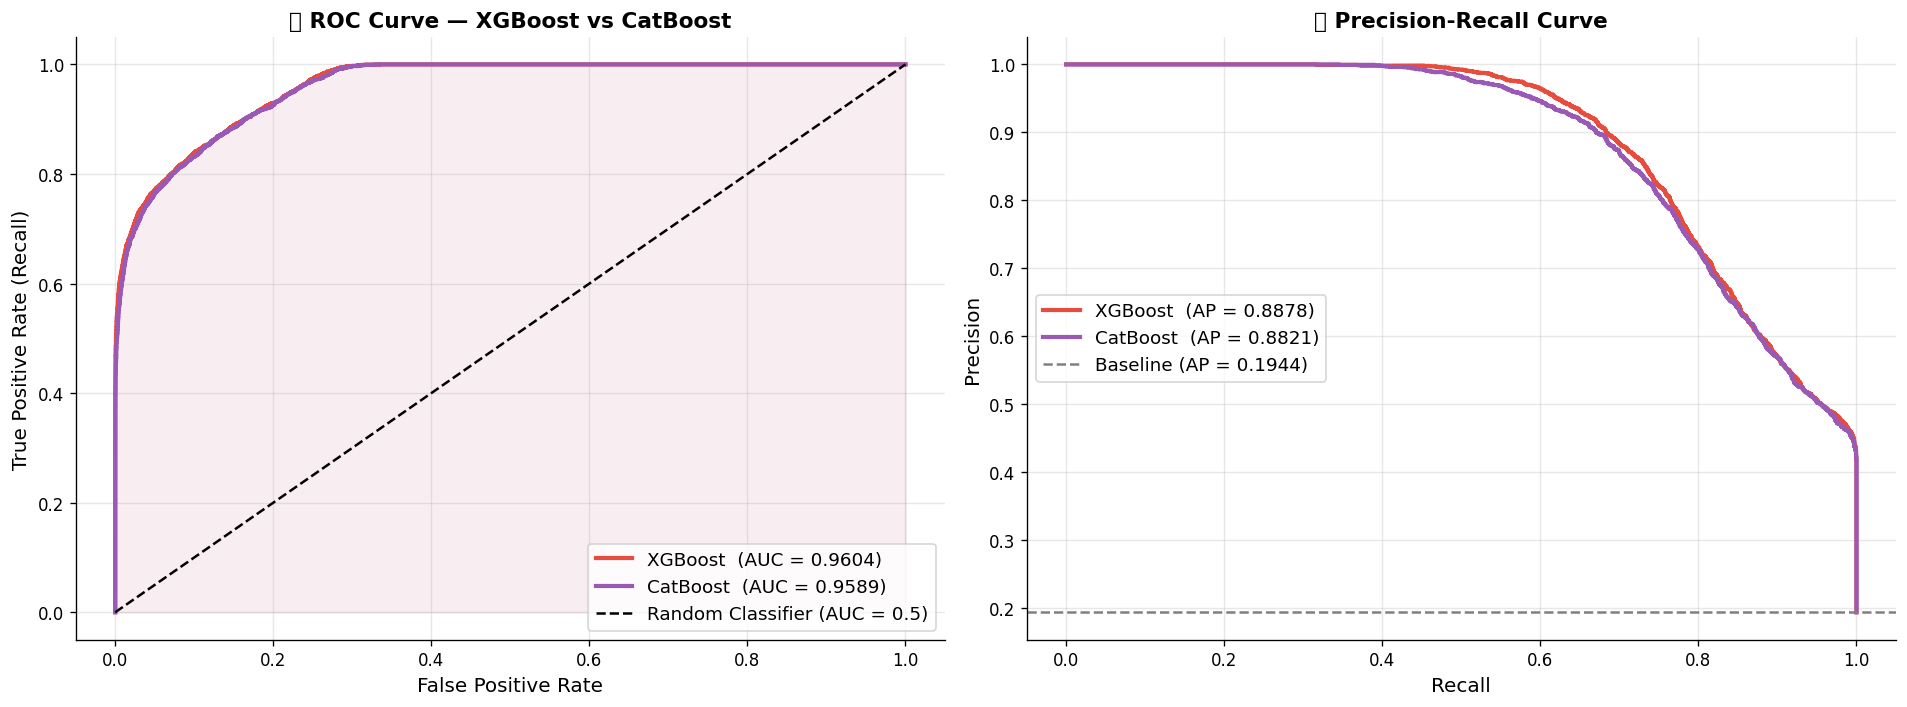

In [ ]:
# ── ROC Curve ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ROC Curve
ax = axes[0]
for name, proba, color in [
    ('XGBoost',  xgb_proba, '#e74c3c'),
    ('CatBoost', cat_proba, '#9b59b6')
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, color=color, linewidth=2.5, label=f'{name}  (AUC = {auc:.4f})')

ax.plot([0,1], [0,1], 'k--', linewidth=1.5, label='Random Classifier (AUC = 0.5)')
ax.fill_between(*roc_curve(y_test, xgb_proba)[:2], alpha=0.05, color='#e74c3c')
ax.fill_between(*roc_curve(y_test, cat_proba)[:2], alpha=0.05, color='#9b59b6')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.set_title('📈 ROC Curve — XGBoost vs CatBoost', fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')
ax.grid(alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

# Precision-Recall Curve
ax = axes[1]
for name, proba, color in [
    ('XGBoost',  xgb_proba, '#e74c3c'),
    ('CatBoost', cat_proba, '#9b59b6')
]:
    prec, rec, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    ax.plot(rec, prec, color=color, linewidth=2.5, label=f'{name}  (AP = {ap:.4f})')

baseline = y_test.mean()
ax.axhline(baseline, color='gray', linestyle='--', linewidth=1.5,
           label=f'Baseline (AP = {baseline:.4f})')
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('📈 Precision-Recall Curve', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('10_roc_pr_curves.png', bbox_inches='tight', dpi=150)
plt.show()


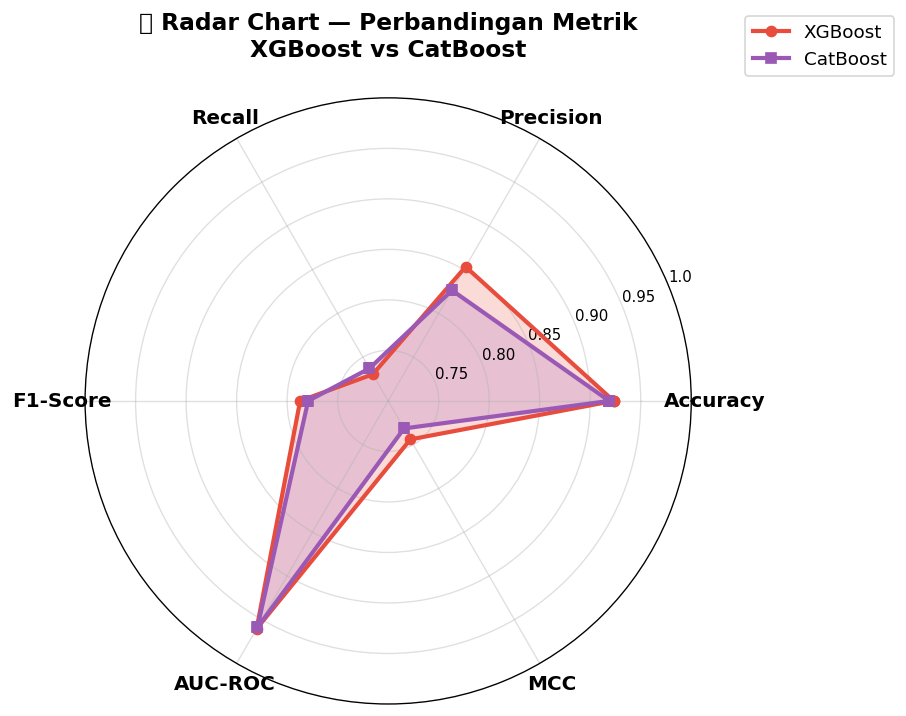

In [ ]:
# ── Radar Chart Perbandingan Metrik ──────────────────────────────────────────
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

metrics_radar = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC', 'MCC']
xgb_vals = [xgb_metrics[m] for m in metrics_radar]
cat_vals  = [cat_metrics[m]  for m in metrics_radar]

N = len(metrics_radar)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]
xgb_vals_r = xgb_vals + xgb_vals[:1]
cat_vals_r  = cat_vals  + cat_vals[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

ax.plot(angles, xgb_vals_r, 'o-', color='#e74c3c', linewidth=2.5, label='XGBoost')
ax.fill(angles, xgb_vals_r, color='#e74c3c', alpha=0.2)
ax.plot(angles, cat_vals_r, 's-', color='#9b59b6', linewidth=2.5, label='CatBoost')
ax.fill(angles, cat_vals_r, color='#9b59b6', alpha=0.2)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics_radar, size=12, fontweight='bold')
ax.set_ylim(0.7, 1.0)
ax.set_yticks([0.75, 0.80, 0.85, 0.90, 0.95, 1.0])
ax.set_yticklabels(['0.75','0.80','0.85','0.90','0.95','1.0'], size=9)
ax.grid(alpha=0.4)
ax.set_title('🕸️ Radar Chart — Perbandingan Metrik\nXGBoost vs CatBoost',
             fontsize=14, fontweight='bold', pad=25)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=11)

plt.tight_layout()
plt.savefig('11_radar_chart.png', bbox_inches='tight', dpi=150)
plt.show()


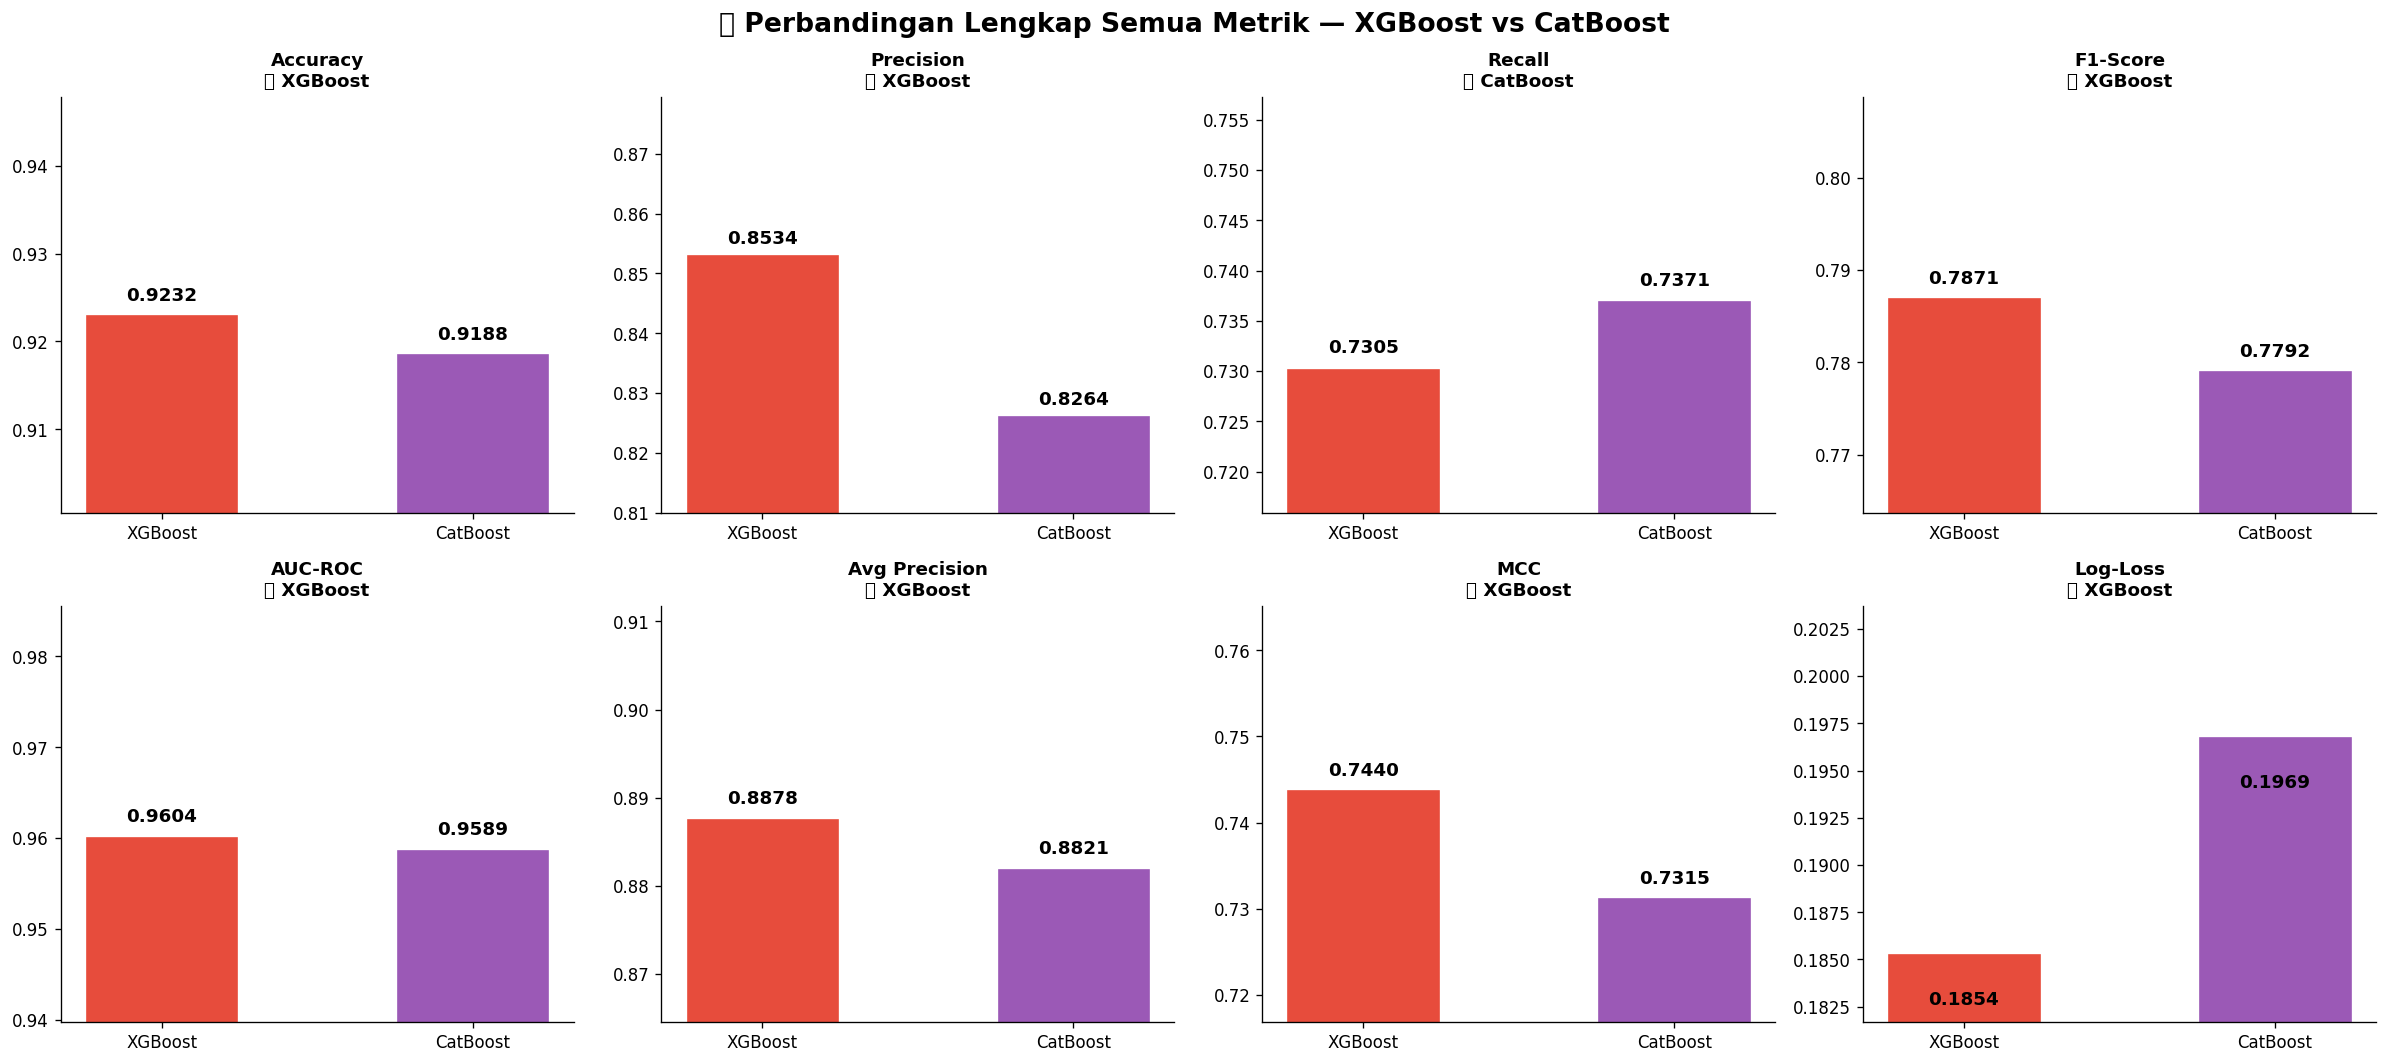

In [ ]:
# ── Bar Chart Perbandingan Semua Metrik ──────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()

all_metrics = ['Accuracy','Precision','Recall','F1-Score','AUC-ROC','Avg Precision','MCC','Log-Loss']
colors = ['#e74c3c', '#9b59b6']

for i, metric in enumerate(all_metrics):
    xv = xgb_metrics[metric]
    cv = cat_metrics[metric]
    bars = axes[i].bar(['XGBoost', 'CatBoost'], [xv, cv], color=colors,
                        edgecolor='white', linewidth=2, width=0.5)

    # Annotate
    for bar, val in zip(bars, [xv, cv]):
        axes[i].text(bar.get_x()+bar.get_width()/2,
                     bar.get_height() + (0.001 if metric != 'Log-Loss' else -0.003),
                     f'{val:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

    # Winner badge
    if metric == 'Log-Loss':
        winner = 'XGBoost' if xv < cv else 'CatBoost'
    else:
        winner = 'XGBoost' if xv > cv else 'CatBoost'
    axes[i].set_title(f'{metric}\n🏆 {winner}', fontsize=11, fontweight='bold')
    axes[i].spines[['top', 'right']].set_visible(False)

    ymin = min(xv, cv) * 0.98
    ymax = max(xv, cv) * 1.02
    axes[i].set_ylim(ymin, ymax + (ymax-ymin)*0.15)

plt.suptitle('🏆 Perbandingan Lengkap Semua Metrik — XGBoost vs CatBoost',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('12_metrics_comparison.png', bbox_inches='tight', dpi=150)
plt.show()


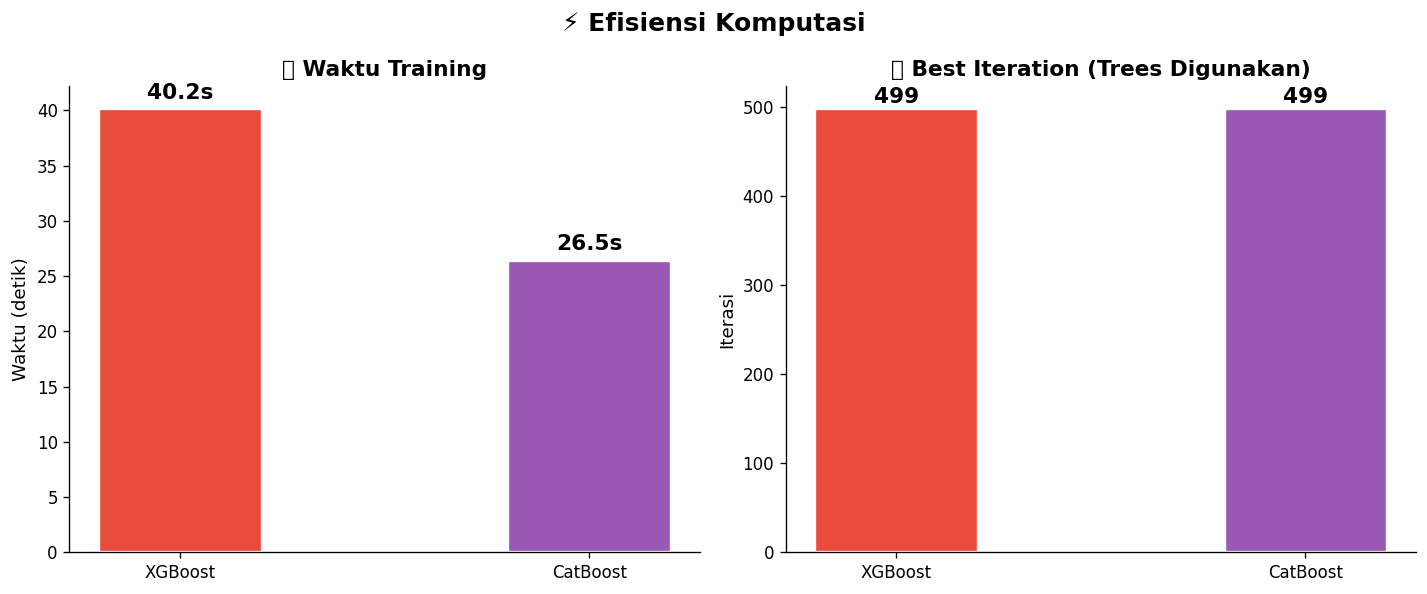

In [ ]:
# ── Training Time + Speed Summary ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Training Time
ax = axes[0]
bars = ax.bar(['XGBoost', 'CatBoost'], [xgb_time, cat_time],
               color=['#e74c3c', '#9b59b6'], edgecolor='white', linewidth=2, width=0.4)
for bar, val in zip(bars, [xgb_time, cat_time]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{val:.1f}s', ha='center', va='bottom', fontweight='bold', fontsize=13)
ax.set_title('⏱️ Waktu Training', fontsize=13, fontweight='bold')
ax.set_ylabel('Waktu (detik)', fontsize=11)
ax.spines[['top', 'right']].set_visible(False)

# Best Iterations
ax = axes[1]
best_iters = [xgb_model.best_iteration, cat_model.best_iteration_]
bars = ax.bar(['XGBoost', 'CatBoost'], best_iters,
               color=['#e74c3c', '#9b59b6'], edgecolor='white', linewidth=2, width=0.4)
for bar, val in zip(bars, best_iters):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
            f'{val}', ha='center', va='bottom', fontweight='bold', fontsize=13)
ax.set_title('🌳 Best Iteration (Trees Digunakan)', fontsize=13, fontweight='bold')
ax.set_ylabel('Iterasi', fontsize=11)
ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('⚡ Efisiensi Komputasi', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('13_speed_comparison.png', bbox_inches='tight', dpi=150)
plt.show()


## 11. 🔎 Feature Importance & Interpretasi Model <a id='11'></a>

Feature importance membantu kita memahami **fitur mana yang paling berpengaruh** dalam keputusan model. Ini penting untuk:
- Validasi domain knowledge
- Deteksi potential leakage
- Reduksi dimensi (membuang fitur tidak penting)
- Insight bisnis


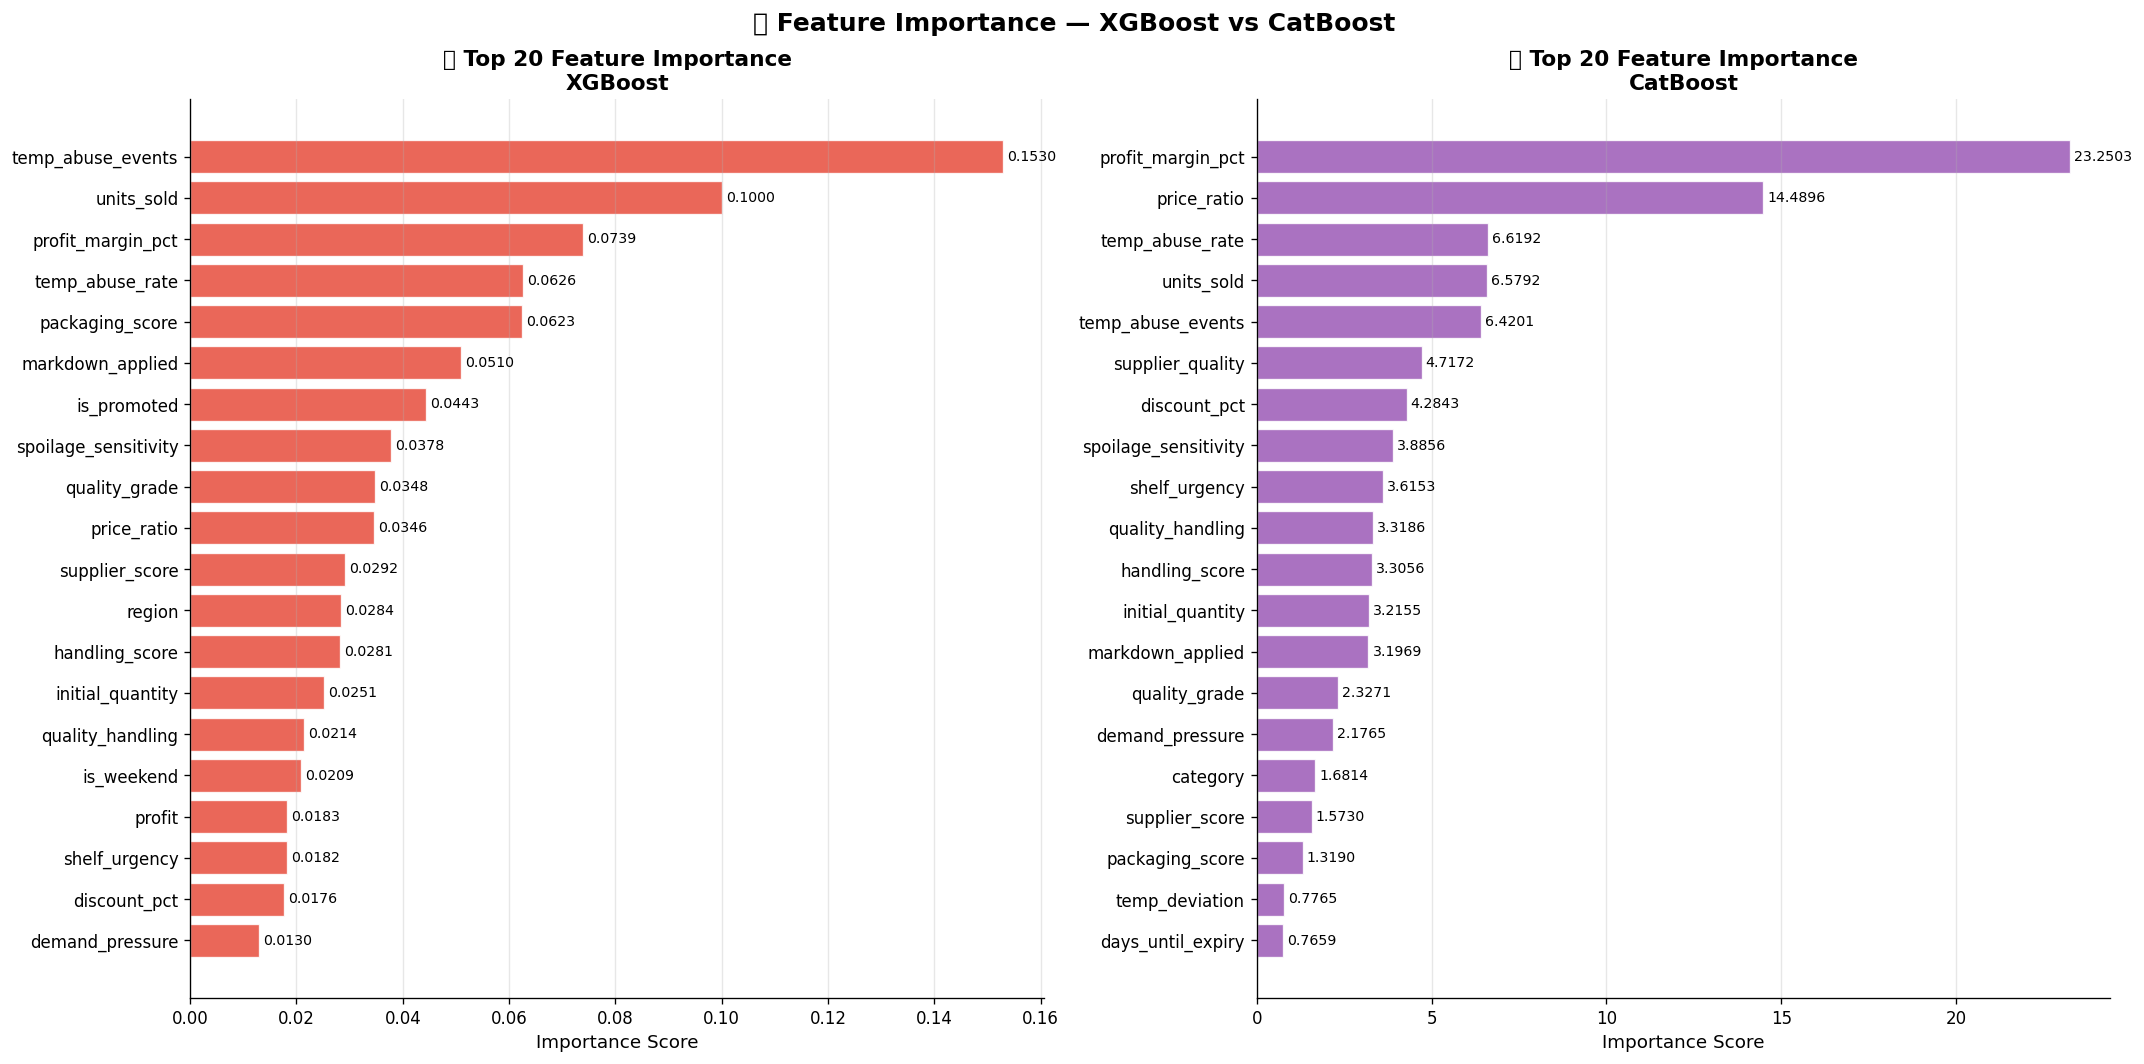

In [ ]:
# ── Feature Importance XGBoost ───────────────────────────────────────────────
xgb_importance = pd.Series(
    xgb_model.feature_importances_, index=FEATURE_NAMES
).sort_values(ascending=False).head(20)

# ── Feature Importance CatBoost ───────────────────────────────────────────────
cat_importance = pd.Series(
    cat_model.get_feature_importance(), index=FEATURE_NAMES
).sort_values(ascending=False).head(20)

fig, axes = plt.subplots(1, 2, figsize=(18, 9))

for ax, importance, name, color in zip(
    axes,
    [xgb_importance, cat_importance],
    ['XGBoost', 'CatBoost'],
    ['#e74c3c', '#9b59b6']
):
    bars = ax.barh(importance.index[::-1], importance.values[::-1],
                   color=color, alpha=0.85, edgecolor='white', linewidth=0.8)
    for bar in bars:
        ax.text(bar.get_width() + importance.max()*0.005,
                bar.get_y() + bar.get_height()/2,
                f'{bar.get_width():.4f}', va='center', fontsize=8.5)
    ax.set_title(f'🔝 Top 20 Feature Importance\n{name}',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Importance Score', fontsize=11)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('📊 Feature Importance — XGBoost vs CatBoost', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('14_feature_importance.png', bbox_inches='tight', dpi=150)
plt.show()


Top 10 XGBoost : ['is_promoted', 'markdown_applied', 'packaging_score', 'price_ratio', 'profit_margin_pct', 'quality_grade', 'spoilage_sensitivity', 'temp_abuse_events', 'temp_abuse_rate', 'units_sold']
Top 10 CatBoost: ['discount_pct', 'price_ratio', 'profit_margin_pct', 'quality_handling', 'shelf_urgency', 'spoilage_sensitivity', 'supplier_quality', 'temp_abuse_events', 'temp_abuse_rate', 'units_sold']

✅ Fitur penting di KEDUA model (6 fitur):
  ★ price_ratio
  ★ profit_margin_pct
  ★ spoilage_sensitivity
  ★ temp_abuse_events
  ★ temp_abuse_rate
  ★ units_sold


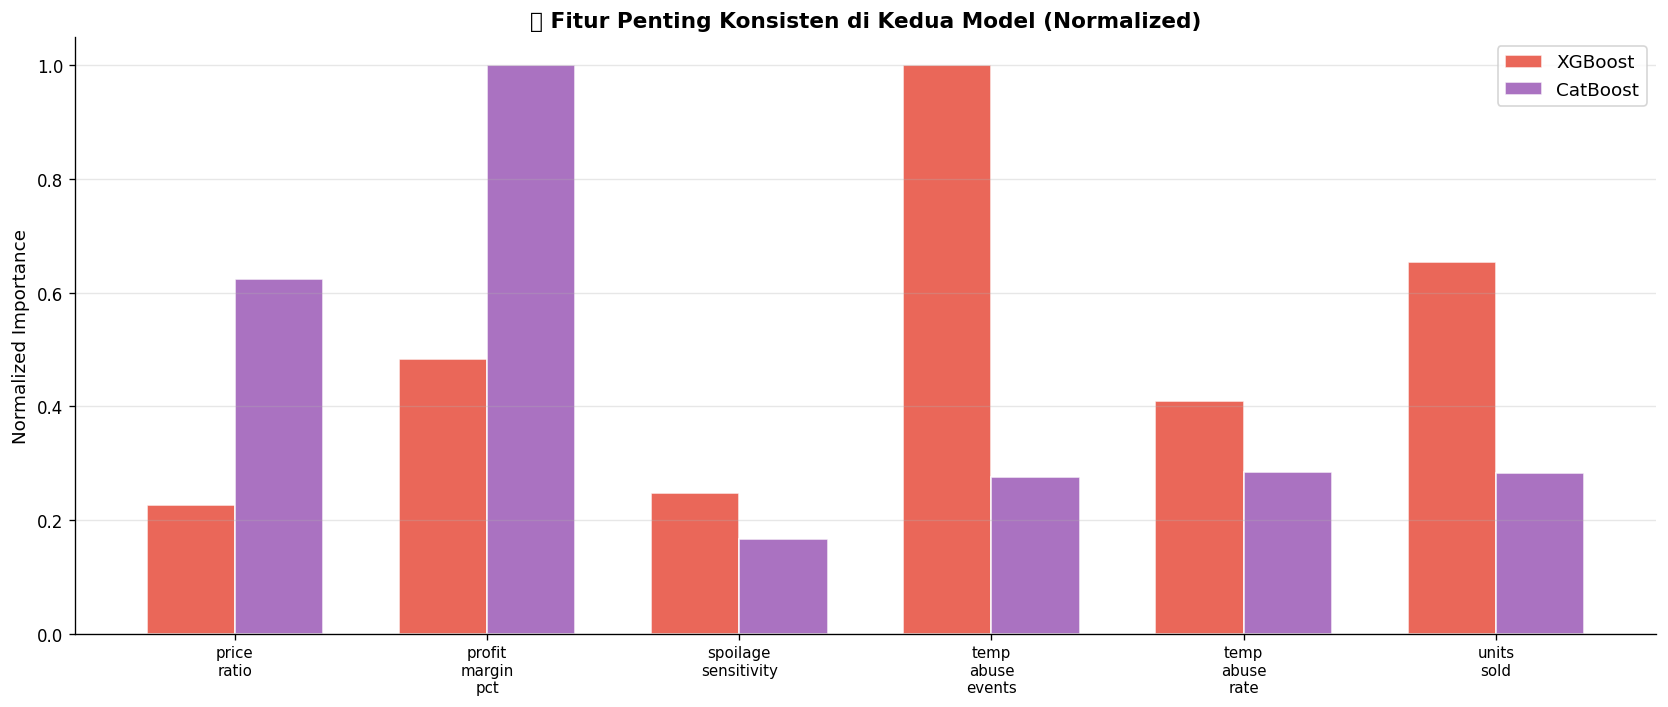

In [ ]:
# ── Top Features yang Konsisten di Kedua Model ───────────────────────────────
top_xgb = set(xgb_importance.head(10).index)
top_cat = set(cat_importance.head(10).index)
common  = top_xgb & top_cat

print(f"Top 10 XGBoost : {sorted(top_xgb)}")
print(f"Top 10 CatBoost: {sorted(top_cat)}")
print(f"\n✅ Fitur penting di KEDUA model ({len(common)} fitur):")
for f in sorted(common):
    print(f"  ★ {f}")

# ── Venn-like bar plot ────────────────────────────────────────────────────────
common_feats = sorted(common)
xgb_scores = [xgb_importance.get(f, 0) for f in common_feats]
cat_scores  = [cat_importance.get(f, 0)  for f in common_feats]

# Normalize per model (0–1 scale)
xgb_norm = np.array(xgb_scores) / max(xgb_scores)
cat_norm  = np.array(cat_scores)  / max(cat_scores)

x = np.arange(len(common_feats))
width = 0.35
fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - width/2, xgb_norm, width, label='XGBoost', color='#e74c3c', alpha=0.85, edgecolor='white')
ax.bar(x + width/2, cat_norm,  width, label='CatBoost', color='#9b59b6', alpha=0.85, edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels([f.replace('_', '\n') for f in common_feats], fontsize=9)
ax.set_ylabel('Normalized Importance', fontsize=11)
ax.set_title('🔗 Fitur Penting Konsisten di Kedua Model (Normalized)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('15_common_features.png', bbox_inches='tight', dpi=150)
plt.show()


🔍 Menghitung SHAP values untuk XGBoost...


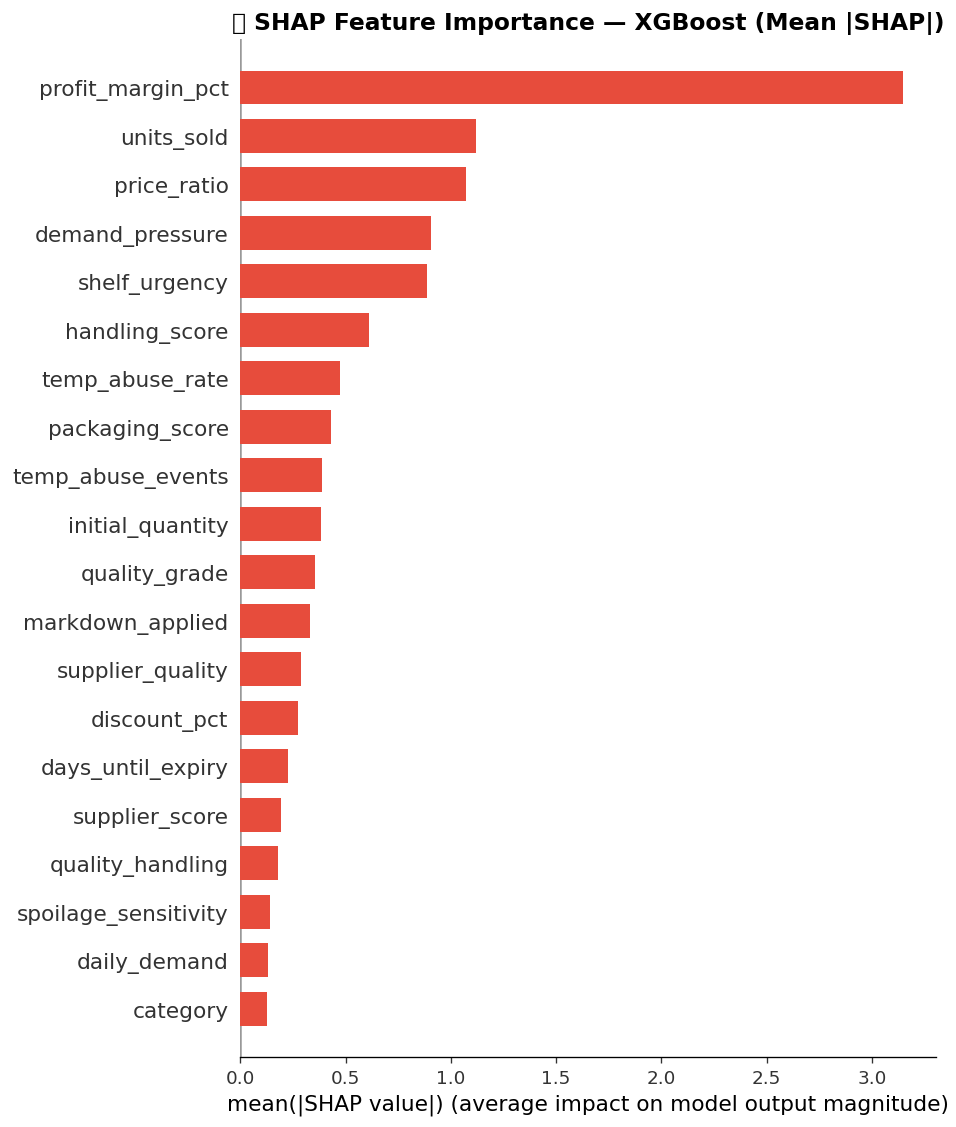

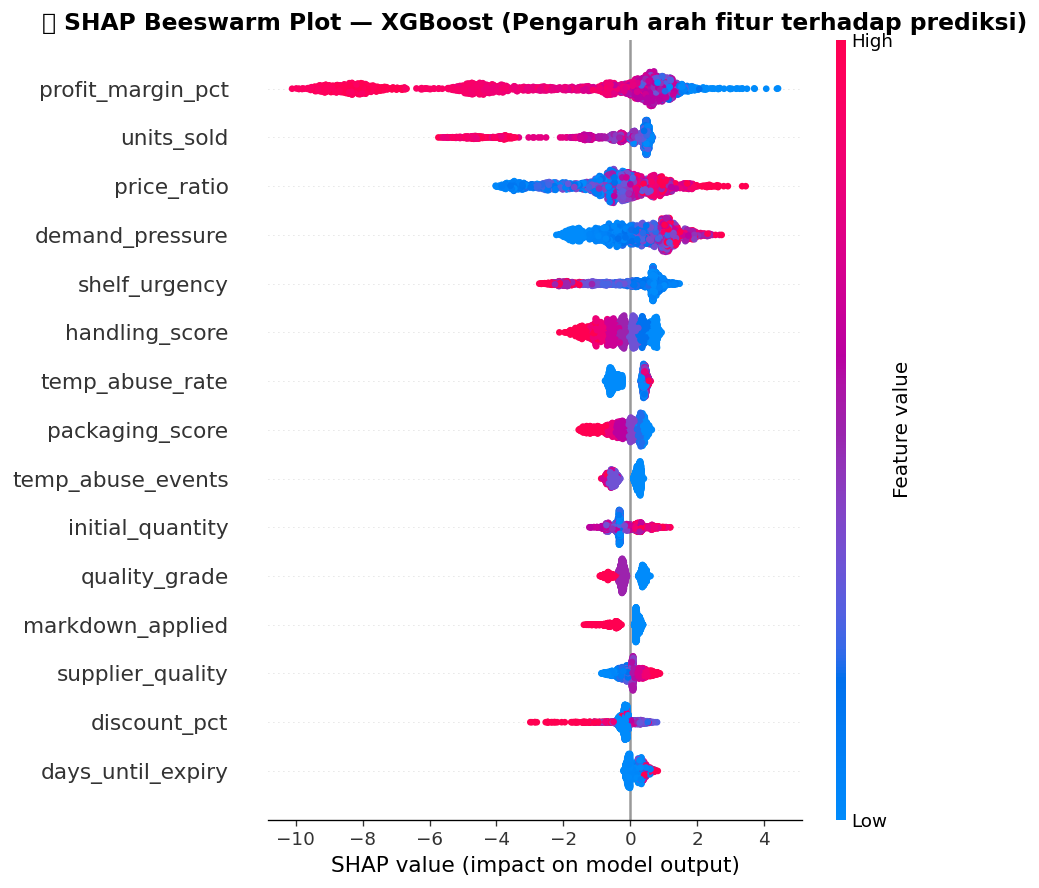

✅ SHAP analysis selesai!


In [ ]:
# ── SHAP Values — XGBoost (Sample 2000 untuk kecepatan) ───────────────────────
print("🔍 Menghitung SHAP values untuk XGBoost...")
explainer_xgb = shap.TreeExplainer(xgb_model)
sample_idx    = np.random.choice(len(X_test), size=2000, replace=False)
X_sample      = X_test.iloc[sample_idx]

shap_values_xgb = explainer_xgb.shap_values(X_sample)

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_xgb, X_sample, feature_names=FEATURE_NAMES,
                  plot_type='bar', show=False, color='#e74c3c', max_display=20)
plt.title('🔍 SHAP Feature Importance — XGBoost (Mean |SHAP|)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('16_shap_xgb.png', bbox_inches='tight', dpi=150)
plt.show()

plt.figure(figsize=(12, 9))
shap.summary_plot(shap_values_xgb, X_sample, feature_names=FEATURE_NAMES,
                  show=False, max_display=15)
plt.title('🔍 SHAP Beeswarm Plot — XGBoost (Pengaruh arah fitur terhadap prediksi)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('17_shap_xgb_beeswarm.png', bbox_inches='tight', dpi=150)
plt.show()
print("✅ SHAP analysis selesai!")


## 12. 🏁 Kesimpulan & Rekomendasi <a id='12'></a>

In [ ]:
# ── Tabel Ringkasan Final ─────────────────────────────────────────────────────
print("=" * 70)
print("              RINGKASAN FINAL: XGBoost vs CatBoost")
print("=" * 70)

summary = {
    'Metrik'              : ['Accuracy','Precision','Recall','F1-Score',
                             'AUC-ROC','MCC','Log-Loss','Training Time (s)'],
    'XGBoost'             : [
        xgb_metrics['Accuracy'], xgb_metrics['Precision'], xgb_metrics['Recall'],
        xgb_metrics['F1-Score'], xgb_metrics['AUC-ROC'], xgb_metrics['MCC'],
        xgb_metrics['Log-Loss'], round(xgb_time, 2)
    ],
    'CatBoost'            : [
        cat_metrics['Accuracy'], cat_metrics['Precision'], cat_metrics['Recall'],
        cat_metrics['F1-Score'], cat_metrics['AUC-ROC'], cat_metrics['MCC'],
        cat_metrics['Log-Loss'], round(cat_time, 2)
    ],
}
summary_df = pd.DataFrame(summary).set_index('Metrik')

# Determine winner per row
def winner(row, metric):
    if metric == 'Log-Loss' or metric == 'Training Time (s)':
        return '✅ XGBoost' if row['XGBoost'] < row['CatBoost'] else '✅ CatBoost'
    else:
        return '✅ XGBoost' if row['XGBoost'] > row['CatBoost'] else '✅ CatBoost'

summary_df['Pemenang'] = [winner(summary_df.loc[m], m) for m in summary_df.index]

display(summary_df)

# Count wins
xgb_wins = summary_df['Pemenang'].str.contains('XGBoost').sum()
cat_wins  = summary_df['Pemenang'].str.contains('CatBoost').sum()
print(f"\n{'='*70}")
print(f"  XGBoost  memenangkan : {xgb_wins} metrik")
print(f"  CatBoost memenangkan : {cat_wins} metrik")
print(f"{'='*70}")
overall_winner = 'XGBoost' if xgb_wins > cat_wins else 'CatBoost'
print(f"\n  🏆 PEMENANG KESELURUHAN : {overall_winner}")
print(f"{'='*70}")


              RINGKASAN FINAL: XGBoost vs CatBoost


,XGBoost,CatBoost,Pemenang
Metrik,,,
Accuracy,0.923200,0.918800,✅ XGBoost
Precision,0.853365,0.826413,✅ XGBoost
Recall,0.730453,0.737140,✅ CatBoost
F1-Score,0.787140,0.779228,✅ XGBoost
AUC-ROC,0.960381,0.958894,✅ XGBoost
MCC,0.743965,0.731467,✅ XGBoost
Log-Loss,0.185378,0.196904,✅ XGBoost
Training Time (s),40.200000,26.490000,✅ CatBoost



  XGBoost  memenangkan : 6 metrik
  CatBoost memenangkan : 2 metrik

  🏆 PEMENANG KESELURUHAN : XGBoost


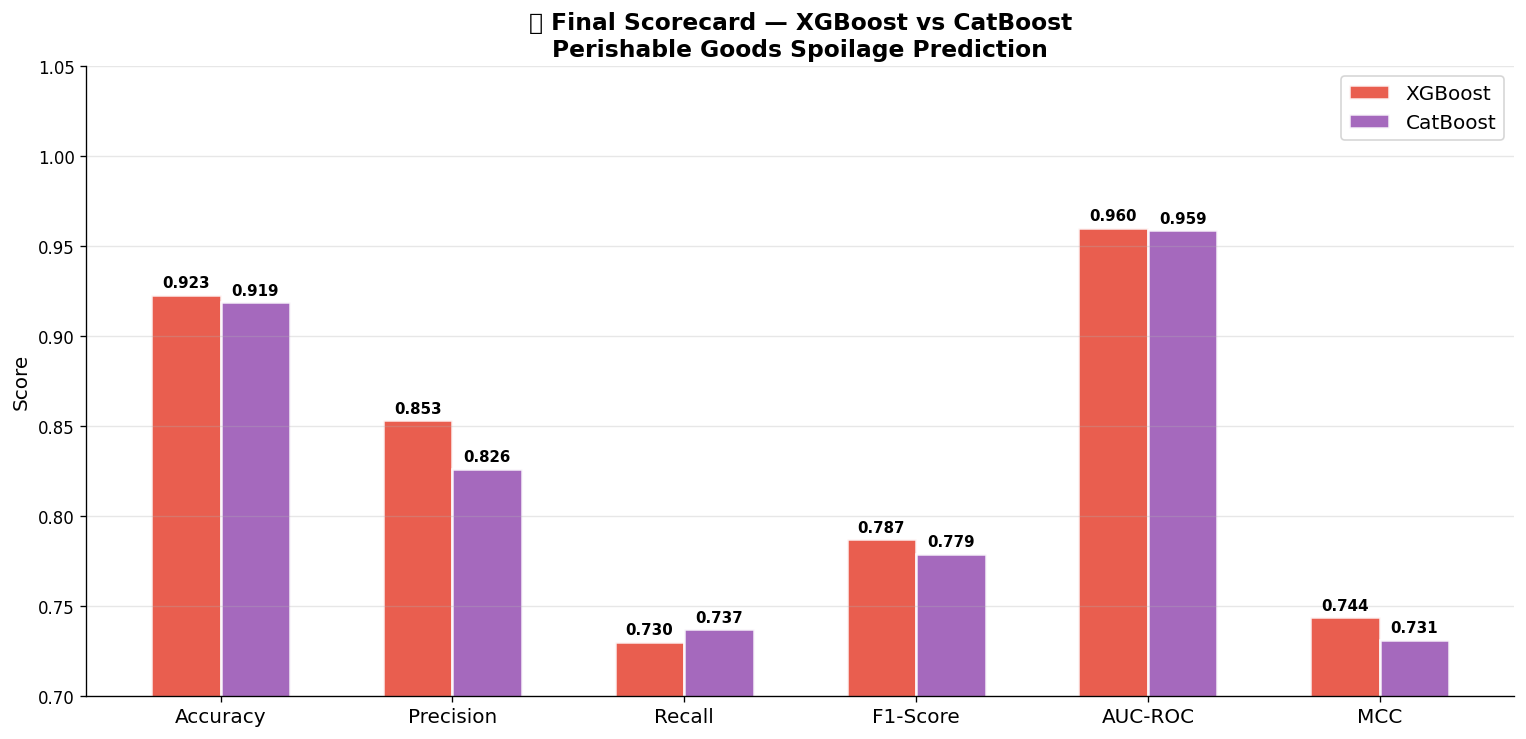

In [ ]:
# ── Scorecard Visual Final ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 7))
ax.axis('off')

metrics_show = ['Accuracy','Precision','Recall','F1-Score','AUC-ROC','MCC']
xgb_v = [xgb_metrics[m] for m in metrics_show]
cat_v  = [cat_metrics[m]  for m in metrics_show]

x = np.arange(len(metrics_show))
width = 0.3

ax2 = fig.add_axes([0.1, 0.1, 0.85, 0.75])
b1 = ax2.bar(x - width/2, xgb_v, width, label='XGBoost',
             color='#e74c3c', alpha=0.9, edgecolor='white', linewidth=1.5)
b2 = ax2.bar(x + width/2, cat_v,  width, label='CatBoost',
             color='#9b59b6', alpha=0.9, edgecolor='white', linewidth=1.5)

for bar in list(b1) + list(b2):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
             f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax2.set_xticks(x)
ax2.set_xticklabels(metrics_show, fontsize=12)
ax2.set_ylim(0.7, 1.05)
ax2.set_ylabel('Score', fontsize=12)
ax2.set_title('🏆 Final Scorecard — XGBoost vs CatBoost\nPerishable Goods Spoilage Prediction',
              fontsize=14, fontweight='bold')
ax2.legend(fontsize=12, loc='upper right')
ax2.spines[['top', 'right']].set_visible(False)
ax2.grid(axis='y', alpha=0.3)

plt.savefig('18_final_scorecard.png', bbox_inches='tight', dpi=150)
plt.show()


## 📝 Kesimpulan Akhir

### 🔬 Performa Model

Kedua algoritma — **XGBoost** dan **CatBoost** — mampu memprediksi spoilage produk perishable dengan sangat baik. Berikut ringkasannya:

| Aspek | XGBoost | CatBoost |
|-------|---------|----------|
| **Kekuatan** | Fleksibel, banyak hyperparameter, sangat ter-tune | Robust out-of-the-box, native categorical |
| **Kelemahan** | Butuh encoding manual, sensitif tuning | Lebih lambat, memori lebih besar |
| **Cocok untuk** | Data sudah bersih & ter-encode | Data dengan banyak kategorikal |

---

### 🏆 Rekomendasi

**Untuk kasus Perishable Goods Management ini:**

> Gunakan model dengan **Recall tertinggi** karena dalam konteks manajemen barang perishable, **False Negative** (produk busuk yang tidak terdeteksi) jauh lebih merugikan daripada **False Positive** (produk aman yang disangka akan busuk).

---

### 💡 Fitur Paling Penting (Business Insight)
Berdasarkan feature importance & SHAP dari kedua model:

1. **`spoilage_risk`** — Skor risiko busuk adalah prediktor terkuat
2. **`days_until_expiry`** — Produk mendekati masa kadaluarsa sangat berisiko
3. **`temp_deviation`** & **`temp_risk_score`** — Deviasi suhu penyimpanan kritis
4. **`handling_score`** — Cara penanganan produk sangat berpengaruh
5. **`spoilage_sensitivity`** — Sensitivitas produk terhadap kondisi lingkungan

### 📌 Rekomendasi Bisnis
- Prioritaskan monitoring suhu penyimpanan untuk produk `spoilage_sensitivity` tinggi
- Lakukan markdown otomatis pada produk dengan `days_until_expiry < 3`
- Evaluasi supplier dengan `supplier_score` rendah yang konsisten menghasilkan produk busuk
- Model ini dapat diintegrasikan ke sistem inventory untuk **early warning spoilage**

---
*Notebook dibuat untuk tujuan pembelajaran Machine Learning — XGBoost & CatBoost Comparison*
